## **0. Apresentação do grupo**
### Fase 1
Número do Grupo: 1
 
 - Guilherme Soares, 62372
 - Duarte Soares, 62371
 - Vitória Correia, 62211

## **1. Introdução**

Este projeto insere-se no contexto da disciplina de **Fundamentos de Aprendizagem Automática**, tendo como objetivo aplicar técnicas de **aprendizagem automática** para analisar e compreender fatores que influenciam o desempenho académico dos estudantes. Através da exploração de dados relacionados com hábitos de estudo, bem-estar e comportamento, pretende-se não só construir modelos preditivos, mas também extrair conhecimento útil que permita interpretar padrões relevantes e apoiar decisões informadas no contexto educativo.

## **1.1 Definição do problema**

O objetivo principal deste projeto é estudar a **eficiência académica** dos estudantes, procurando perceber se o sucesso académico depende apenas do número de horas de estudo ou se resulta de uma combinação mais ampla de fatores, como **capacidade de foco, qualidade do descanso, hábitos digitais e bem-estar geral**.

Esta questão é relevante porque, em contextos educativos atuais, os estudantes estão expostos a múltiplas fontes de distração e a padrões de vida que podem influenciar significativamente o seu desempenho. Assim, mais do que estudar durante mais tempo, importa compreender **que fatores estão associados a estudar melhor**.

A eficiência académica é analisada através de duas dimensões complementares:  
- **Dimensão comportamental**, relacionada com o nível de foco durante o estudo  
- **Dimensão de resultado**, refletida no desempenho obtido em avaliação  

Com base nesta perspetiva, foram definidos dois cenários preditivos complementares:

- **Cenário de Regressão:** estimar o valor de `focus_index` como **proxy do nível de concentração durante o estudo**  
- **Cenário de Classificação:** prever se um estudante pertence ao **grupo de desempenho elevado no exame**, através da variável binária `high_exam_score`, construída a partir de `exam_score`  

A variável `high_exam_score` foi definida considerando como classe positiva os estudantes cujo `exam_score` se encontra no **quartil superior da distribuição(acima do Q3)**, permitindo identificar um grupo com desempenho academicamente elevado de forma consistente com os dados observados.

Desta forma, o projeto procura responder simultaneamente a duas questões:

- **Que fatores ajudam a explicar o nível de foco de um estudante?**  
- **Com que grau de precisão é possível prever se um estudante pertence ao grupo de desempenho elevado no exame?**  

A combinação destes dois cenários permite analisar a eficiência académica de forma mais completa, relacionando não apenas o resultado final, mas também uma dimensão comportamental intermédia essencial: **o foco**.

## **1.2 Stakeholders**

Os resultados deste estudo podem ser úteis para diferentes intervenientes no contexto académico.

- **Estudantes:** podem obter informação sobre se o aumento do tempo de estudo, por si só, é suficiente para melhorar o desempenho, ou se fatores como foco, descanso e bem-estar têm um papel mais determinante  
- **Docentes, mentores e tutores:** podem utilizar estes resultados para sugerir estratégias de estudo mais eficazes e personalizadas, ajustadas aos perfis e necessidades dos estudantes  
- **Serviços de apoio ao estudante:** podem beneficiar destas conclusões para desenhar intervenções preventivas orientadas para hábitos saudáveis, equilíbrio digital e melhoria das condições de aprendizagem  
- **Coordenação académica ou instituições de ensino:** podem usar este tipo de análise para apoiar decisões relacionadas com acompanhamento pedagógico, prevenção de insucesso e promoção do bem-estar académico  

Assim, o valor do projeto não está apenas na construção de modelos preditivos, mas também na possibilidade de produzir conhecimento útil para **apoiar decisões educativas baseadas em dados** e promover estratégias de aprendizagem mais sustentáveis.

## **1.3 Imports**

Nesta secção são importadas as bibliotecas necessárias para o desenvolvimento do projeto. Estas incluem ferramentas para manipulação de dados, visualização, pré-processamento, construção de pipelines, treino de modelos e avaliação de desempenho.

In [2]:
# Manipulação de dados
import pandas as pd
import numpy as np

# Visualização
import matplotlib.pyplot as plt
import seaborn as sns

# Pré-processamento
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, RobustScaler, StandardScaler

# Divisão de dados e validação
from sklearn.model_selection import train_test_split, cross_validate

# Modelos baseline
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.tree import DecisionTreeRegressor, DecisionTreeClassifier
from sklearn.linear_model import Lasso, Ridge

from sklearn.ensemble import RandomForestClassifier

# Métricas de avaliação
from sklearn.metrics import (
    mean_squared_error, r2_score, mean_absolute_error,
    accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, silhouette_score
)
from sklearn.model_selection import train_test_split, cross_validate, KFold, StratifiedKFold
from sklearn.model_selection import RandomizedSearchCV, GridSearchCV
# Display de tabelas (Jupyter)
from IPython.display import display

# Visualização de métricas
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.tree import plot_tree


from sklearn.feature_selection import (
    SelectKBest,
    mutual_info_classif,
    SelectFromModel,
    mutual_info_regression,
    SequentialFeatureSelector,
)
from sklearn.cluster import KMeans
from sklearn.ensemble import RandomForestClassifier

from sklearn.ensemble import RandomForestRegressor

from sklearn.pipeline import Pipeline

from sklearn.ensemble import AdaBoostClassifier

from sklearn.model_selection import StratifiedKFold, GridSearchCV

from sklearn.ensemble import GradientBoostingRegressor

from sklearn.neural_network import MLPClassifier

from sklearn.ensemble import RandomForestClassifier


## **2. Carregamento e inspeção inicial dos dados**

Nesta fase é realizado o carregamento do dataset, a validação das variáveis-alvo definidas e a preparação dos dados para análise. É também construída a variável de classificação e efetuada uma inspeção inicial dos dados.

Importa salientar que esta etapa tem um caráter **exploratório e descritivo**. As transformações finais necessárias para modelação, como imputação, codificação e escalonamento, serão posteriormente integradas num pipeline, garantindo consistência entre treino e teste e evitando data leakage.

### **2.1 Configuração e definição de targets**

In [3]:
link = r"Dados_Projeto\student_records_missing.csv"

#estas sao as colunas que podem ser usadas como targets
allowed_cols = ["focus_index", "burnout_level", "productivity_score", "exam_score"]

# Targets definidos
target_reg = "focus_index"
target_clf_base = "exam_score"

### **2.2 Funções auxiliares para inspeção dos dados**

Foram definidas funções auxiliares para resumir a informação presente no dataset, permitindo analisar variáveis numéricas e categóricas, bem como identificar valores em falta.

In [4]:
def summarize_numeric(df):
    num_cols = df.select_dtypes(include=np.number).columns.tolist()

    if not num_cols:
        return pd.DataFrame()

    summary = df[num_cols].agg(["count", "mean", "std", "min", "median", "max"]).T
    summary["missing"] = df[num_cols].isna().sum()

    return summary.round(3)


def summarize_categorical(df):
    cat_cols = df.select_dtypes(exclude=np.number).columns.tolist()

    rows = []

    for col in cat_cols:
        s = df[col]
        mode = s.mode(dropna=True)

        rows.append({
            "variable": col,
            "count": s.notna().sum(),
            "missing": s.isna().sum(),
            "unique": s.nunique(dropna=True),
            "mode": mode.iloc[0] if not mode.empty else None
        })

    if rows:
        return pd.DataFrame(rows).set_index("variable")

    return pd.DataFrame()

### **2.3 Carregamento dos dados e criação das variáveis-alvo**

Nesta etapa, o dataset é carregado, são validados os targets definidos e é construída a variável de classificação.

A variável `high_exam_score` é definida com base no quartil superior de `exam_score`, sendo atribuída a classe 1 aos estudantes com desempenho elevado e 0 aos restantes.

In [5]:
def load_project_data(fname, target_reg, target_clf_base):
    df = pd.read_csv(fname)

    # Validação dos targets
    for target in [target_reg, target_clf_base]:
        if target not in allowed_cols:
            raise ValueError(f"Target inválido: {target}. Targets permitidos: {allowed_cols}")

        if target not in df.columns:
            raise ValueError(f"Target '{target}' não encontrado no dataset.")

    # Criar variável de classificação (quartil superior)
    threshold = df[target_clf_base].quantile(0.75)

    df["high_exam_score"] = (df[target_clf_base] >= threshold).astype(int)

    # Separação de features e targets
    cols_to_drop = [
        "student_id",         # identificador sem valor preditivo
        "focus_index",        # target de regressão
        "exam_score",         # base do target de classificação
        "high_exam_score",    # target de classificação
        "burnout_level",      # não usado neste problema
        "productivity_score"  # não usado neste problema
    ]

    X_raw = df.drop(columns=cols_to_drop, errors="ignore").copy()
    y_reg = df[target_reg].copy()
    y_clf = df["high_exam_score"].copy()

    return df, X_raw, y_reg, y_clf, threshold

### **2.4 Inspeção inicial dos dados**

Nesta fase é realizada uma análise descritiva do dataset, incluindo tipos de variáveis, distribuição dos dados e identificação de valores em falta.

In [6]:

pd.set_option("display.max_rows", None)
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 200)

df, X_raw, y_reg, y_clf, exam_threshold = load_project_data(
    link, target_reg, target_clf_base
)

# Tabela geral com informação essencial
df_info = pd.DataFrame({
    "n_rows": [df.shape[0]],
    "n_columns": [df.shape[1]],
    "target_reg": [target_reg],
    "target_clf": ["high_exam_score"],
    "threshold": [round(exam_threshold, 3)],
    "class_0_count": [(y_clf == 0).sum()],
    "class_1_count": [(y_clf == 1).sum()],
    "class_1_ratio": [round((y_clf == 1).mean(), 3)]
})

display(df_info)

# Tabela de missing values
missing_df = pd.DataFrame({
    "missing_count": X_raw.isna().sum(),
    "missing_ratio": X_raw.isna().mean()
}).sort_values(by="missing_ratio", ascending=False)

display(missing_df)

# Resumo numérico
display(summarize_numeric(X_raw))

# Resumo categórico
cat_summary = summarize_categorical(X_raw)
if not cat_summary.empty:
    display(cat_summary)

,n_rows,n_columns,target_reg,target_clf,threshold,class_0_count,class_1_count,class_1_ratio
0,5000,22,focus_index,high_exam_score,27.4,3748,1252,0.25


,missing_count,missing_ratio
mental_health_score,750,0.15
caffeine_intake_mg,500,0.10
screen_time_hours,400,0.08
social_media_hours,250,0.05
gender,150,0.03
academic_level,100,0.02
study_hours,0,0.00
age,0,0.00
gaming_hours,0,0.00
online_classes_hours,0,0.00


,count,mean,std,min,median,max,missing
age,5000.0,20.520,2.870,16.0,20.000,25.00,0
study_hours,5000.0,4.540,1.822,0.0,4.530,11.84,0
self_study_hours,5000.0,2.479,1.178,0.0,2.480,7.41,0
online_classes_hours,5000.0,2.012,0.984,0.0,2.010,6.00,0
social_media_hours,4750.0,2.995,1.467,0.0,2.975,8.28,250
gaming_hours,5000.0,1.565,1.111,0.0,1.490,5.64,0
sleep_hours,5000.0,7.016,1.164,4.0,7.010,10.00,0
screen_time_hours,4600.0,6.986,2.476,1.0,6.955,15.30,400
exercise_minutes,5000.0,74.536,42.932,0.0,75.000,149.00,0
caffeine_intake_mg,4500.0,251.127,143.810,0.0,251.000,499.00,500


,count,missing,unique,mode
variable,,,,
gender,4850,150,3,Male
academic_level,4900,100,3,Postgraduate
internet_quality,5000,0,3,Good


## **3. Pré-processamento**

O pré-processamento foi definido com o objetivo de preparar o dataset para modelação de forma **reprodutível, consistente e metodologicamente correta**, respeitando a natureza mista das variáveis disponíveis e evitando **data leakage**.

A análise inicial dos dados mostrou a presença de:
- variáveis **numéricas** e **categóricas**
- **valores em falta** em ambos os tipos de variáveis
- diferenças de **escala** entre variáveis numéricas
- sinais de possível **assimetria** e presença de valores extremos em algumas features

Deste modo, foi construído um pipeline de pré-processamento com estratégias específicas para cada tipo de variável.

### **3.1 Justificação técnica do pré-processamento**

#### **Tratamento de valores em falta**

A análise inicial revelou a presença de valores em falta em várias variáveis, com maior incidência em `mental_health_score` (~15%), `caffeine_intake_mg` (~10%) e `screen_time_hours` (~8%).

Dado que estes valores não são negligenciáveis e que a remoção de observações implicaria perda significativa de informação, optou-se por estratégias de imputação.

Nas variáveis numéricas foi utilizada imputação pela **mediana**, uma vez que esta é robusta à presença de valores extremos. Esta decisão é suportada pela análise estatística, onde se observam amplitudes elevadas e possíveis outliers, por exemplo:
- `caffeine_intake_mg` varia entre 0 e ~500, com desvio padrão elevado (~144)
- `screen_time_hours` apresenta uma amplitude considerável (até ~15 horas)

Estas características tornam inadequado o uso da média, que é sensível a valores extremos.

Nas variáveis categóricas foi utilizada imputação pela **categoria mais frequente**, permitindo preservar a distribuição observada dos dados sem introduzir categorias artificiais.

#### **Codificação de variáveis categóricas**

As variáveis categóricas identificadas (`gender`, `academic_level` e `internet_quality`) apresentam um número reduzido de categorias distintas (3 categorias cada) e não possuem uma ordem natural.

Neste contexto, a utilização de codificação ordinal introduziria relações artificiais entre categorias (por exemplo, assumir que "Postgraduate" > "Undergraduate"), o que não é semanticamente correto.

Assim, foi utilizada codificação **One-Hot Encoding**, que transforma cada categoria numa variável binária independente, permitindo uma representação adequada das variáveis nominais.

A utilização de `drop="first"` reduz redundância entre variáveis dummy, sendo particularmente relevante para modelos lineares.


#### **Escalonamento de variáveis numéricas**

A análise estatística evidenciou diferenças significativas de escala entre variáveis numéricas, por exemplo:
- `study_hours` com valores até ~12
- `screen_time_hours` até ~15
- `caffeine_intake_mg` até ~500
- `exercise_minutes` até ~149

Adicionalmente, algumas variáveis apresentam elevada variabilidade e possíveis valores extremos, como indicado pelos desvios padrão elevados.

Dado este contexto, foi utilizado **RobustScaler**, que centra os dados na mediana e escala com base no intervalo interquartil (IQR), sendo menos sensível a outliers do que métodos baseados na média e desvio padrão.

Esta escolha é **consistente com a imputação pela mediana**, uma vez que ambas são robustas a outliers e adequadas a distribuições assimétricas, garantindo coerência no tratamento das variáveis numéricas.

Embora o escalonamento não seja essencial para modelos baseados em árvores, foi incluído no pipeline global para garantir consistência na preparação dos dados e permitir uma comparação justa entre diferentes modelos.

### **3.2 Identificação e separação das variáveis**

As variáveis foram separadas em numéricas e categóricas com base no seu tipo de dados, permitindo aplicar estratégias de pré-processamento específicas a cada grupo.

In [7]:
# Identificação dos tipos de variáveis
numeric_features = X_raw.select_dtypes(include=np.number).columns.tolist()
categorical_features = X_raw.select_dtypes(exclude=np.number).columns.tolist()

# Tabela resumo
feature_groups_df = pd.DataFrame({
    "feature_type": ["numeric", "categorical"],
    "n_features": [len(numeric_features), len(categorical_features)]
})

display(feature_groups_df)

# Lista de variáveis numéricas
numeric_df = pd.DataFrame({"numeric_features": pd.Series(numeric_features)})
display(numeric_df)

# Lista de variáveis categóricas
categorical_df = pd.DataFrame({"categorical_features": pd.Series(categorical_features)})
display(categorical_df)

,feature_type,n_features
0,numeric,13
1,categorical,3


,numeric_features
0,age
1,study_hours
2,self_study_hours
3,online_classes_hours
4,social_media_hours
5,gaming_hours
6,sleep_hours
7,screen_time_hours
8,exercise_minutes
9,caffeine_intake_mg


,categorical_features
0,gender
1,academic_level
2,internet_quality


### **3.3 Construção do pipeline de pré-processamento**

O pipeline final foi construído com duas transformações distintas:
- um sub-pipeline para variáveis numéricas, com imputação pela mediana seguida de `RobustScaler`
- um sub-pipeline para variáveis categóricas, com imputação pela categoria mais frequente seguida de `OneHotEncoder`

Estas transformações são combinadas num `ColumnTransformer`, permitindo aplicar automaticamente o tratamento adequado a cada grupo de variáveis.

In [8]:
# Sub-pipeline numérico:
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", RobustScaler())
])

# Sub-pipeline categórico:
categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore", drop="first"))
])

# Preprocessador global
preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ],
    remainder="drop"
)

### **3.4 Aplicação do pipeline para inspeção da transformação**

Nesta fase, o pipeline é aplicado apenas com o objetivo de **inspecionar o efeito das transformações** sobre os dados. Esta operação permite verificar:

- a eliminação de valores em falta
- o aumento do número de features após a codificação das variáveis categóricas
- o efeito do escalonamento sobre as variáveis numéricas

Importa salientar que, nesta fase, o pipeline é aplicado apenas para observar o efeito das transformações nos dados. Na modelação, o mesmo pipeline será integrado nos modelos, garantindo que todas as transformações são aprendidas apenas com os dados de treino, evitando data leakage.

In [9]:
# Aplicação do pipeline apenas para inspeção da transformação
X_processed = preprocessor.fit_transform(X_raw)

# Nomes das features transformadas
feature_names_out = preprocessor.get_feature_names_out()

# Conversão para DataFrame
if hasattr(X_processed, "toarray"):
    X_processed_df = pd.DataFrame(X_processed.toarray(), columns=feature_names_out)
else:
    X_processed_df = pd.DataFrame(X_processed, columns=feature_names_out)

# Tabela resumo da transformação
preprocessing_summary_df = pd.DataFrame({
    "n_features_before": [X_raw.shape[1]],
    "n_features_after": [X_processed_df.shape[1]],
    "missing_before": [int(X_raw.isna().sum().sum())],
    "missing_after": [int(X_processed_df.isna().sum().sum())]
})

display(preprocessing_summary_df)

# Resumo estatístico das variáveis numéricas após transformação
num_cols_processed = [col for col in X_processed_df.columns if col.startswith("num__")]
display(summarize_numeric(X_processed_df[num_cols_processed]))

,n_features_before,n_features_after,missing_before,missing_after
0,16,19,2150,0


,count,mean,std,min,median,max,missing
num__age,5000.0,0.104,0.574,-0.800,0.0,1.000,0
num__study_hours,5000.0,0.004,0.726,-1.805,0.0,2.912,0
num__self_study_hours,5000.0,-0.001,0.723,-1.521,0.0,3.025,0
num__online_classes_hours,5000.0,0.001,0.718,-1.467,0.0,2.912,0
num__social_media_hours,5000.0,0.010,0.749,-1.558,0.0,2.777,0
num__gaming_hours,5000.0,0.045,0.665,-0.892,0.0,2.485,0
num__sleep_hours,5000.0,0.004,0.740,-1.914,0.0,1.901,0
num__screen_time_hours,5000.0,0.009,0.759,-1.903,0.0,2.666,0
num__exercise_minutes,5000.0,-0.006,0.572,-1.000,0.0,0.987,0
num__caffeine_intake_mg,5000.0,0.001,0.623,-1.146,0.0,1.132,0


## **4. Modelos baseline**

Nesta fase foram selecionados modelos baseline simples e interpretáveis, com o objetivo de estabelecer uma referência inicial de desempenho. Estes modelos permitem avaliar o comportamento dos dados antes da utilização de abordagens mais complexas.

Para a tarefa de regressão foi utilizada a **Regressão Linear** como modelo principal, sendo complementada por uma **Árvore de Decisão** para comparação.

Para a tarefa de classificação foi utilizada a **Regressão Logística** como modelo principal, sendo igualmente considerada uma **Árvore de Decisão** como alternativa.

A escolha destes modelos deve-se ao facto de serem:
- **interpretáveis**, permitindo compreender a relação entre variáveis e target
- **simples**, servindo como ponto de partida para avaliação
- **representativos de diferentes famílias de modelos** (lineares e baseados em árvores)

Todos os modelos são treinados utilizando pipelines que integram o pré-processamento definido anteriormente, garantindo consistência entre treino e teste e evitando data leakage.

### **4.1 Divisão dos dados**

Os dados foram divididos em dois subconjuntos:
- **conjunto de treino**: utilizado para treino dos modelos e validação cruzada
- **conjunto de teste**: utilizado para avaliação do desempenho dos modelos

Na tarefa de classificação foi utilizada estratificação (`stratify=y_clf`) para preservar a distribuição das classes entre os subconjuntos.

In [10]:
RANDOM_STATE = 42

X_train, X_test, y_train_reg, y_test_reg, y_train_clf, y_test_clf = train_test_split(
    X_raw,
    y_reg,
    y_clf,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=y_clf
)

split_df = pd.DataFrame({
    "dataset": ["train", "test"],
    "n_samples": [X_train.shape[0], X_test.shape[0]]
})

display(split_df)

,dataset,n_samples
0,train,4000
1,test,1000


### **4.2 Definição dos modelos baseline**

Os modelos foram definidos através de pipelines que integram o pré-processamento com o algoritmo de aprendizagem, garantindo que todas as transformações são aplicadas corretamente em cada fase do treino e avaliação.

Para os modelos de classificação foi utilizado `class_weight="balanced"`, de forma a compensar o desbalanceamento entre classes, atribuindo maior peso à classe minoritária e evitando que o modelo favoreça excessivamente a classe dominante.

Nas árvores de decisão foi fixada uma profundidade máxima de 5 nesta fase inicial, de forma a controlar a complexidade do modelo e reduzir o risco de sobreajuste, mantendo ainda assim interpretabilidade.

In [11]:

# Regressão
reg_models = {
    "LinearRegression": Pipeline(steps=[
        ("preprocessor", preprocessor),
        ("model", LinearRegression())
    ]),
    "DecisionTreeRegressor": Pipeline(steps=[
        ("preprocessor", preprocessor),
        ("model", DecisionTreeRegressor(
            random_state=RANDOM_STATE,
            max_depth=5
        ))
    ])
}

# Classificação
clf_models = {
    "LogisticRegression": Pipeline(steps=[
        ("preprocessor", preprocessor),
        ("model", LogisticRegression(
            max_iter=2000,
            random_state=RANDOM_STATE,
            class_weight="balanced"
        ))
    ]),
    "DecisionTreeClassifier": Pipeline(steps=[
        ("preprocessor", preprocessor),
        ("model", DecisionTreeClassifier(
            random_state=RANDOM_STATE,
            max_depth=5,
            class_weight="balanced"
        ))
    ])
}

### **4.3 Métricas de avaliação**

Foram definidas métricas adequadas a cada tipo de problema, distinguindo entre uma **métrica primária**, utilizada como principal critério de comparação entre modelos, e uma **métrica secundária**, utilizada para complementar a análise.

#### **Regressão**

Na tarefa de regressão foi definida como métrica primária o **RMSE (Root Mean Squared Error)**. Esta métrica penaliza mais fortemente erros elevados, sendo particularmente adequada neste contexto, onde grandes desvios na previsão do `focus_index` representam previsões significativamente incorretas.

Como métrica secundária foi utilizado o **MAE (Mean Absolute Error)**, que mede o erro absoluto médio entre os valores previstos e os valores reais. Ao contrário do RMSE, o MAE não penaliza desproporcionalmente erros muito elevados, oferecendo uma perspetiva complementar mais robusta face a outliers e permitindo uma interpretação mais direta do erro médio nas unidades da variável alvo.

#### **Classificação**

Na tarefa de classificação foi definido como métrica primária o **F1-score**, uma vez que combina precisão e recall numa única métrica. Esta escolha é adequada devido ao desbalanceamento entre classes (~25% classe positiva), tornando a accuracy isolada potencialmente enganadora.

Como métrica secundária foi utilizada a **ROC-AUC**, que avalia a capacidade do modelo em distinguir entre classes de forma independente do threshold de decisão. Esta métrica complementa o F1-score porque permite avaliar a capacidade discriminativa do modelo mesmo quando o threshold de classificação não é ótimo.

Como métrica complementar foi mantida a **accuracy**, por fornecer uma leitura global simples da proporção de previsões corretas. No entanto, esta métrica não foi usada como principal critério de comparação, devido ao desbalanceamento entre classes.

In [12]:
def evaluate_regression(model, X_train, X_test, y_train, y_test, name):
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    return {
        "model": name,
        "rmse_test": np.sqrt(mean_squared_error(y_test, y_pred)),
        "mae_test": mean_absolute_error(y_test, y_pred)
    }


def evaluate_classification(model, X_train, X_test, y_train, y_test, model_name):
    model.fit(X_train, y_train)

    y_pred_test = model.predict(X_test)
    y_prob_test = model.predict_proba(X_test)[:, 1]

    return {
        "model": model_name,
        "f1": f1_score(y_test, y_pred_test, zero_division=0),
        "roc_auc": roc_auc_score(y_test, y_prob_test),
        "accuracy": accuracy_score(y_test, y_pred_test)
    }

### **4.4 Treino e avaliação dos modelos**

Os modelos foram treinados e avaliados nos conjuntos de treino e teste, sendo os resultados apresentados sob a forma de tabelas comparativas.

In [13]:
# Regressão
reg_results = []
for name, model in reg_models.items():
    reg_results.append(
        evaluate_regression(model, X_train, X_test, y_train_reg, y_test_reg, name)
    )

reg_results_df = pd.DataFrame(reg_results).sort_values(by="rmse_test")

display(reg_results_df)


# Classificação
clf_results = []
for name, model in clf_models.items():
    clf_results.append(
        evaluate_classification(model, X_train, X_test, y_train_clf, y_test_clf, name)
    )

clf_results_df = pd.DataFrame(clf_results).sort_values(by="f1", ascending=False)

clf_results_df = clf_results_df[[
    "model",
    "f1",
    "roc_auc",
    "accuracy"
]]

display(clf_results_df)

,model,rmse_test,mae_test
0,LinearRegression,5.527448,4.319604
1,DecisionTreeRegressor,7.054088,5.575350


,model,f1,roc_auc,accuracy
0,LogisticRegression,0.729373,0.922347,0.836
1,DecisionTreeClassifier,0.615883,0.834328,0.763


### **4.5 Validação cruzada**

Para garantir a robustez dos resultados, foi utilizada validação cruzada sobre o conjunto de treino, complementando a avaliação realizada no conjunto de teste.

Na tarefa de regressão foi utilizado `KFold`, enquanto na classificação foi utilizado `StratifiedKFold`, de forma a preservar a proporção das classes em cada fold.

Esta abordagem permite obter estimativas mais estáveis do desempenho dos modelos e avaliar a consistência dos resultados face a diferentes divisões dos dados.

In [14]:
kf_reg = KFold(n_splits=15, shuffle=True, random_state=RANDOM_STATE)
skf_clf = StratifiedKFold(n_splits=15, shuffle=True, random_state=RANDOM_STATE)

reg_scoring = {
    "rmse": "neg_root_mean_squared_error",
    "mae": "neg_mean_absolute_error"
}

clf_scoring = {
    "f1": "f1",
    "roc_auc": "roc_auc",
    "accuracy": "accuracy"
}

# -------------------------
# Regressão
# -------------------------
cv_reg_results = []

for name, model in reg_models.items():
    scores = cross_validate(
        model,
        X_train,
        y_train_reg,
        cv=kf_reg,
        scoring=reg_scoring,
        return_train_score=True,
        n_jobs=-1
    )

    cv_reg_results.append({
        "model": name,

        "cv_rmse_train_mean": -scores["train_rmse"].mean(),
        "cv_rmse_test_mean": -scores["test_rmse"].mean(),

        "cv_mae_train_mean": -scores["train_mae"].mean(),
        "cv_mae_test_mean": -scores["test_mae"].mean(),

        "cv_rmse_test_std": scores["test_rmse"].std(),
        "cv_mae_test_std": scores["test_mae"].std()
    })

cv_reg_df = pd.DataFrame(cv_reg_results).sort_values(by="cv_rmse_test_mean")

display(cv_reg_df[[
    "model",
    "cv_rmse_test_mean",
    "cv_mae_test_mean",
    "cv_rmse_test_std",
    "cv_mae_test_std"
]])

# -------------------------
# Classificação
# -------------------------
cv_clf_results = []

for name, model in clf_models.items():
    scores = cross_validate(
        model,
        X_train,
        y_train_clf,
        cv=skf_clf,
        scoring=clf_scoring,
        return_train_score=True,
        n_jobs=-1
    )

    cv_clf_results.append({
        "model": name,

        "cv_f1_train_mean": scores["train_f1"].mean(),
        "cv_f1_test_mean": scores["test_f1"].mean(),

        "cv_roc_auc_train_mean": scores["train_roc_auc"].mean(),
        "cv_roc_auc_test_mean": scores["test_roc_auc"].mean(),

        "cv_accuracy_train_mean": scores["train_accuracy"].mean(),
        "cv_accuracy_test_mean": scores["test_accuracy"].mean(),

        "cv_f1_test_std": scores["test_f1"].std(),
        "cv_roc_auc_test_std": scores["test_roc_auc"].std(),
        "cv_accuracy_test_std": scores["test_accuracy"].std()
    })

cv_clf_df = pd.DataFrame(cv_clf_results).sort_values(
    by="cv_f1_test_mean",
    ascending=False
)

display(cv_clf_df[[
    "model",
    "cv_f1_test_mean",
    "cv_roc_auc_test_mean",
    "cv_accuracy_test_mean",
    "cv_f1_test_std",
    "cv_roc_auc_test_std",
    "cv_accuracy_test_std"
]])

,model,cv_rmse_test_mean,cv_mae_test_mean,cv_rmse_test_std,cv_mae_test_std
0,LinearRegression,5.599146,4.401073,0.222937,0.220667
1,DecisionTreeRegressor,7.235252,5.761560,0.241742,0.217978


,model,cv_f1_test_mean,cv_roc_auc_test_mean,cv_accuracy_test_mean,cv_f1_test_std,cv_roc_auc_test_std,cv_accuracy_test_std
0,LogisticRegression,0.712907,0.922026,0.829741,0.022397,0.011331,0.013913
1,DecisionTreeClassifier,0.646482,0.844063,0.791486,0.039039,0.028638,0.027531


### **4.5.1 Comparação entre conjunto de teste e validação cruzada**

De forma a avaliar a consistência dos resultados, foi realizada uma comparação direta entre o desempenho obtido no conjunto de teste (one split) e os resultados médios da validação cruzada.

Esta comparação permite verificar se os resultados obtidos não dependem de uma divisão específica dos dados, reforçando a fiabilidade das conclusões.

In [15]:
# -------------------------
# Regressão
# -------------------------
reg_compare_df = reg_results_df.merge(
    cv_reg_df[["model", "cv_rmse_test_mean", "cv_mae_test_mean"]],
    on="model",
    how="left"
)

# Reordenar colunas
reg_compare_df = reg_compare_df.rename(columns={
    "rmse_test": "RMSE (Test)",
    "cv_rmse_test_mean": "RMSE (CV)",
    "mae_test": "MAE (Test)",
    "cv_mae_test_mean": "MAE (CV)"
})

display(reg_compare_df)

# -------------------------
# Classificação
# -------------------------
clf_compare_df = clf_results_df.merge(
    cv_clf_df[[
        "model",
        "cv_f1_test_mean",
        "cv_roc_auc_test_mean",
        "cv_accuracy_test_mean"
    ]],
    on="model",
    how="left"
)

clf_compare_df = clf_compare_df[[
    "model",
    "f1", "cv_f1_test_mean",
    "roc_auc", "cv_roc_auc_test_mean",
    "accuracy", "cv_accuracy_test_mean"
]]

# Reordenar colunas
clf_compare_df = clf_compare_df.rename(columns={
    "f1": "F1-score (Test)",
    "cv_f1_test_mean": "F1-score (CV)",
    "roc_auc": "ROC-AUC (Test)",
    "cv_roc_auc_test_mean": "ROC-AUC (CV)",
    "accuracy": "Accuracy (Test)",
    "cv_accuracy_test_mean": "Accuracy (CV)"
})

display(clf_compare_df)

,model,RMSE (Test),MAE (Test),RMSE (CV),MAE (CV)
0,LinearRegression,5.527448,4.319604,5.599146,4.401073
1,DecisionTreeRegressor,7.054088,5.575350,7.235252,5.761560


,model,F1-score (Test),F1-score (CV),ROC-AUC (Test),ROC-AUC (CV),Accuracy (Test),Accuracy (CV)
0,LogisticRegression,0.729373,0.712907,0.922347,0.922026,0.836,0.829741
1,DecisionTreeClassifier,0.615883,0.646482,0.834328,0.844063,0.763,0.791486


### **4.5.2 Interpretação dos resultados**

Os resultados obtidos através de validação cruzada permitem tirar conclusões consistentes sobre o desempenho e a capacidade de generalização dos modelos, com base nas métricas definidas previamente.

Na tarefa de regressão, a Regressão Linear apresenta melhor desempenho segundo a métrica principal, o **RMSE**, evidenciando erros médios inferiores em comparação com a Árvore de Decisão. A métrica secundária, **MAE**, confirma esta tendência, apresentando também valores mais baixos, o que indica menor erro absoluto médio nas previsões. A proximidade entre os valores obtidos no conjunto de teste e na validação cruzada em ambas as métricas sugere boa capacidade de generalização e ausência de overfitting.

Por outro lado, a Árvore de Decisão apresenta valores superiores tanto de **RMSE** como de **MAE**, indicando pior desempenho preditivo. As diferenças observadas entre os resultados de teste e validação cruzada sugerem uma menor capacidade de generalização, com sinais ligeiros de overfitting.

Na tarefa de classificação, a Regressão Logística apresenta melhor desempenho segundo a métrica principal, o **F1-score**, indicando um bom equilíbrio entre precisão e recall. A métrica secundária, **ROC-AUC**, apresenta também valores elevados, indicando uma forte capacidade de distinção entre classes e uma boa ordenação das observações segundo a probabilidade de pertencerem à classe positiva.

A diferença entre o **ROC-AUC** elevado (~0.92) e o **F1-score** mais moderado (~0.71) indica que, embora o modelo tenha uma forte capacidade discriminativa, o threshold de decisão utilizado na classificação binária poderá não ser totalmente ótimo, resultando em alguns erros de classificação. A **accuracy**, utilizada como métrica complementar, fornece uma leitura global da proporção de previsões corretas, mas não é usada como principal critério de comparação devido ao desbalanceamento entre classes.

A reduzida variabilidade do **F1-score** entre folds confirma a estabilidade do modelo, indicando que o seu desempenho é consistente face a diferentes divisões dos dados.

A Árvore de Decisão apresenta valores inferiores tanto de **F1-score** como de **ROC-AUC**, indicando pior desempenho na tarefa de classificação e menor capacidade discriminativa entre classes. A **accuracy**, enquanto métrica complementar, confirma também um desempenho global inferior. Apesar de apresentar alguma estabilidade, o modelo revela-se globalmente menos eficaz.

De forma geral, considerando as métricas principais, secundárias e complementares definidas, os modelos lineares (Regressão Linear e Regressão Logística) demonstram melhor desempenho e maior capacidade de generalização nesta fase do projeto. Na classificação, o **F1-score** sustenta a escolha da Regressão Logística como melhor baseline, enquanto o **ROC-AUC** reforça a sua superior capacidade discriminativa.

### **4.6 Representações gráficas dos modelos**

Para complementar a avaliação quantitativa dos modelos baseline, são apresentadas algumas representações gráficas que permitem interpretar melhor o comportamento dos modelos e a forma como utilizam as variáveis disponíveis.

Nesta fase, são mostradas:
- a **matriz de confusão** da Regressão Logística, por ser o melhor baseline de classificação
- o **gráfico dos coeficientes** da Regressão Logística
- uma **visualização simplificada da Árvore de Decisão para classificação**
- o **gráfico dos coeficientes** da Regressão Linear

#### **4.6.1 Matriz de confusão - Regressão Logística**

A matriz de confusão permite visualizar o número de classificações corretas e incorretas em cada classe, complementando métricas como F1-score, ROC-AUC e accuracy.

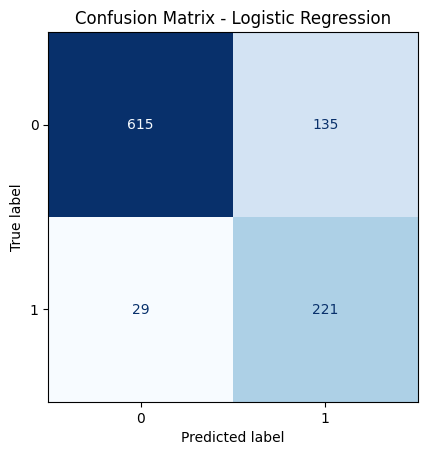

In [16]:
# Treino do modelo logístico
log_model = clf_models["LogisticRegression"]
log_model.fit(X_train, y_train_clf)

# Previsões no conjunto de teste
y_pred_log = log_model.predict(X_test)

# Matriz de confusão
ConfusionMatrixDisplay.from_predictions(
    y_test_clf,
    y_pred_log,
    cmap="Blues",
    colorbar=False
)
plt.title("Confusion Matrix - Logistic Regression")
plt.show()

A matriz de confusão mostra que o modelo reduz os falsos negativos (29), identificando a maioria dos estudantes com desempenho elevado, mas aumenta os falsos positivos (135). Este efeito está associado ao `class_weight="balanced"`, favorecendo o recall e o F1-score, embora prejudique a precisão e a accuracy. 

#### **4.6.2 Coeficientes - Regressão Logística**

Na Regressão Logística, os coeficientes representam o efeito das variáveis no log-odds da classe positiva (`high_exam_score = 1`). Coeficientes positivos estão associados a um aumento da probabilidade prevista de desempenho elevado, enquanto coeficientes negativos indicam o efeito oposto.

,feature,coefficient,abs_coefficient
12,num__mental_health_score,3.263903,3.263903
1,num__study_hours,2.446864,2.446864
11,num__upcoming_deadline,-1.428927,1.428927
6,num__sleep_hours,1.204831,1.204831
10,num__part_time_job,-0.919474,0.919474
4,num__social_media_hours,-0.540719,0.540719
7,num__screen_time_hours,-0.458556,0.458556
8,num__exercise_minutes,0.333295,0.333295
2,num__self_study_hours,0.324237,0.324237
5,num__gaming_hours,-0.300927,0.300927


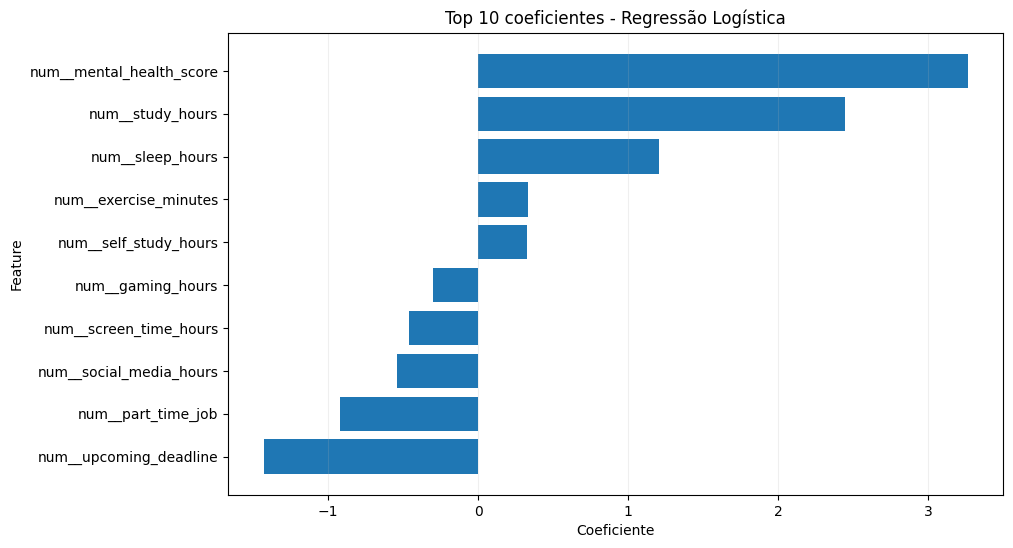

In [17]:
# Extração dos coeficientes
log_features = log_model.named_steps["preprocessor"].get_feature_names_out()
log_coefs = log_model.named_steps["model"].coef_[0]

log_coef_df = pd.DataFrame({
    "feature": log_features,
    "coefficient": log_coefs,
    "abs_coefficient": np.abs(log_coefs)
}).sort_values(by="abs_coefficient", ascending=False)

display(log_coef_df.head(10))

# Gráfico dos coeficientes mais influentes
top_log = log_coef_df.head(10).sort_values(by="coefficient")

plt.figure(figsize=(10, 6))
plt.barh(top_log["feature"], top_log["coefficient"])
plt.xlabel("Coeficiente")
plt.ylabel("Feature")
plt.title("Top 10 coeficientes - Regressão Logística")
plt.grid(axis="x", alpha=0.2)
plt.show()

<a id="462-coeficientes-regressao-logistica"></a>
O gráfico mostra que variáveis como `mental_health_score`, `study_hours` e `sleep_hours` têm maior influência positiva na probabilidade de desempenho elevado, enquanto fatores como `upcoming_deadline`, `part_time_job` e tempo de distração (`social_media_hours`, `screen_time_hours`, `gaming_hours`) estão associados a uma redução dessa probabilidade, contribuindo para a interpretação do modelo que suporta o bom desempenho observado nas métricas **(ROC-AUC e F1-score).**

#### **4.6.3 Visualização da Árvore de Decisão para Classificação**

A árvore de decisão permite uma representação visual direta das regras utilizadas pelo modelo para separar as classes. Para manter a legibilidade, a visualização foi limitada aos primeiros níveis da árvore.

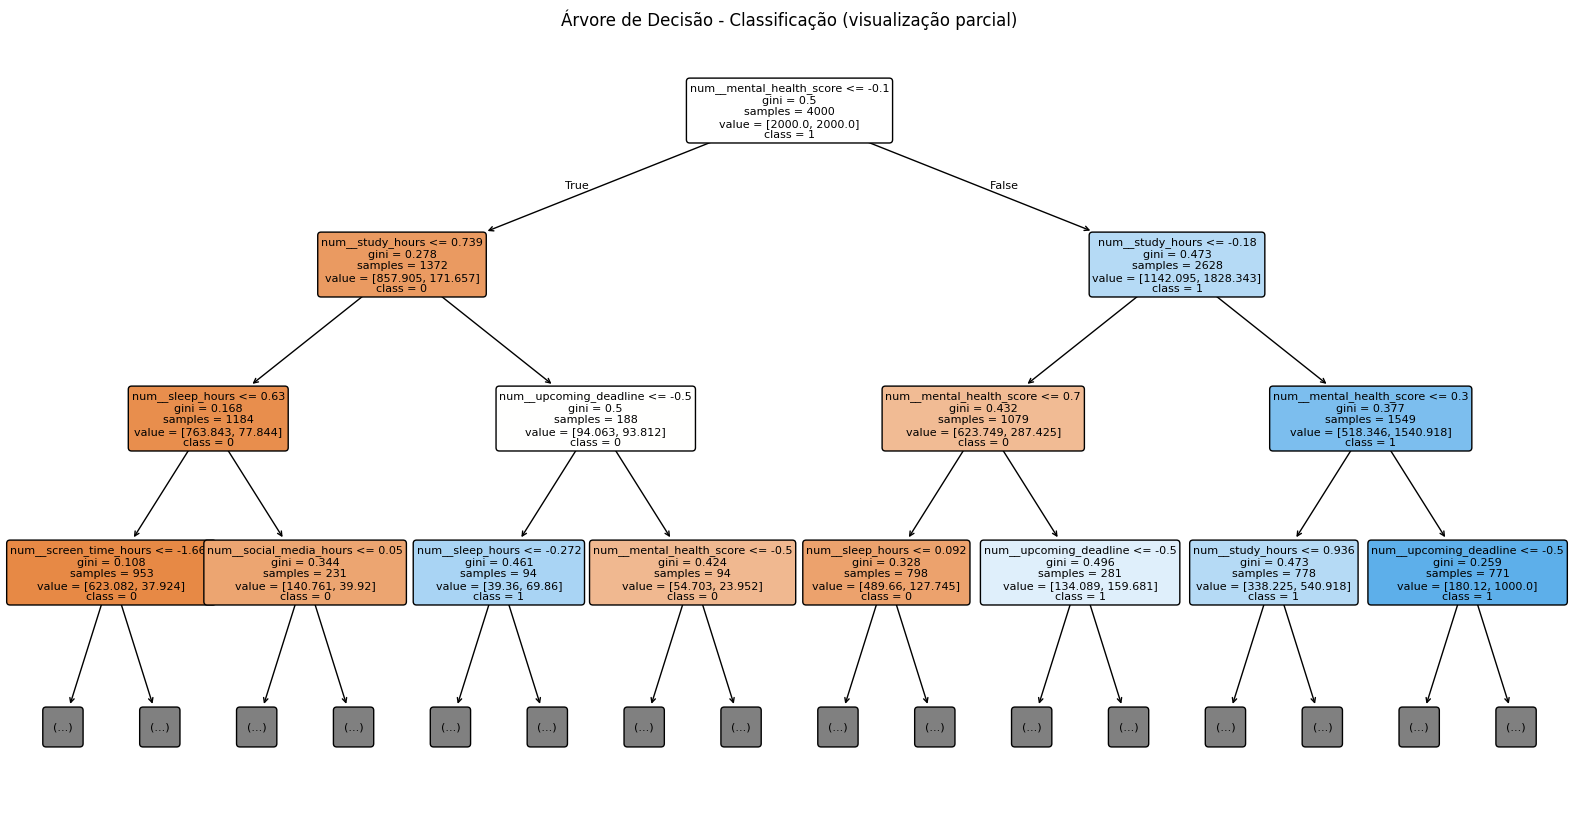

In [18]:
# Treino da árvore de classificação
dt_clf_model = clf_models["DecisionTreeClassifier"]
dt_clf_model.fit(X_train, y_train_clf)

# Extração do estimador e nomes das features
dt_clf_estimator = dt_clf_model.named_steps["model"]
dt_clf_features = dt_clf_model.named_steps["preprocessor"].get_feature_names_out()

# Visualização parcial da árvore
plt.figure(figsize=(20, 10)) #por (70,10) caso queira visualizar a arvore toda
plot_tree(
    dt_clf_estimator,
    feature_names=dt_clf_features,
    class_names=["0", "1"],
    filled=True,
    rounded=True,
    max_depth=3,
    fontsize=8
)
plt.title("Árvore de Decisão - Classificação (visualização parcial)")
plt.show()

A árvore de decisão mostra que variáveis como `mental_health_score` e `study_hours` surgem nos primeiros níveis de decisão, indicando forte importância na separação das classes. No entanto, a presença de várias divisões sucessivas e nós com menor pureza sugere que o modelo captura padrões mais específicos dos dados, o que está alinhado com o desempenho inferior nas métricas **(F1-score e ROC-AUC)** e com sinais de **menor capacidade de generalização face à Regressão Logística.**

#### **4.6.4 Coeficientes - Regressão Linear**

Na Regressão Linear, os coeficientes indicam a direção e magnitude da associação entre cada variável e o valor previsto de `focus_index`. Coeficientes positivos indicam associação direta com o foco, enquanto coeficientes negativos indicam associação inversa.

,feature,coefficient,abs_coefficient
12,num__mental_health_score,9.855409,9.855409
1,num__study_hours,6.381992,6.381992
4,num__social_media_hours,-3.952030,3.952030
2,num__self_study_hours,3.096844,3.096844
5,num__gaming_hours,-2.638262,2.638262
6,num__sleep_hours,2.270612,2.270612
17,cat__internet_quality_Good,-0.441090,0.441090
13,cat__gender_Male,-0.218950,0.218950
0,num__age,-0.208410,0.208410
8,num__exercise_minutes,-0.178965,0.178965


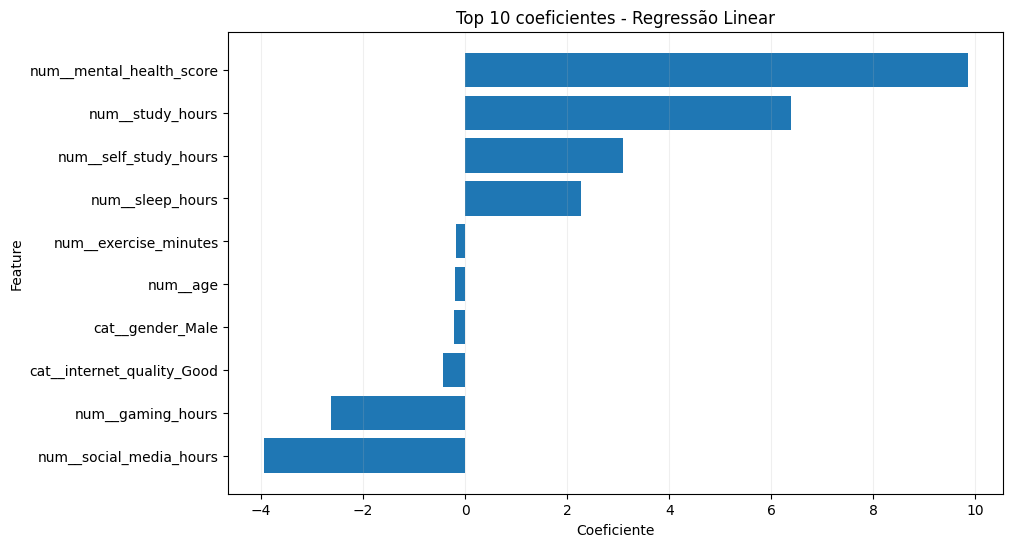

In [19]:
# Treino do modelo linear
lin_model = reg_models["LinearRegression"]
lin_model.fit(X_train, y_train_reg)

# Extração dos coeficientes
lin_features = lin_model.named_steps["preprocessor"].get_feature_names_out()
lin_coefs = lin_model.named_steps["model"].coef_

lin_coef_df = pd.DataFrame({
    "feature": lin_features,
    "coefficient": lin_coefs,
    "abs_coefficient": np.abs(lin_coefs)
}).sort_values(by="abs_coefficient", ascending=False)

display(lin_coef_df.head(10))

# Gráfico dos coeficientes mais influentes
top_lin = lin_coef_df.head(10).sort_values(by="coefficient")

plt.figure(figsize=(10, 6))
plt.barh(top_lin["feature"], top_lin["coefficient"])
plt.xlabel("Coeficiente")
plt.ylabel("Feature")
plt.title("Top 10 coeficientes - Regressão Linear")
plt.grid(axis="x", alpha=0.2)
plt.show()

O gráfico mostra que variáveis como `mental_health_score` e `study_hours` têm maior impacto positivo na previsão do nível de foco, seguidas por `self_study_hours` e `sleep_hours`, enquanto fatores associados a distração, como `social_media_hours` e `gaming_hours`, apresentam impacto negativo. Estes resultados são consistentes com o bom desempenho do modelo de regressão (baixo RMSE e R² elevado), indicando que o modelo consegue captar relações relevantes entre hábitos dos estudantes e o nível de foco.

### **4.7 Análise de erro**

Para complementar a avaliação dos modelos, foi realizada uma análise de erro com o objetivo de identificar padrões associados às previsões incorretas.

Esta análise permite ir além das métricas globais, inspecionando casos específicos onde o modelo falha, contribuindo para uma melhor compreensão das suas limitações.

Na **regressão**, foram analisadas as observações com **maior erro absoluto entre o valor real e o valor previsto.**

Na **classificação**, foram **inspecionados os casos em que o modelo erra a classe, distinguindo entre falsos positivos e falsos negativos.**

Esta abordagem permite identificar potenciais causas para o erro, como:
- presença de outliers
- relações não lineares não captadas pelos modelos
- observações próximas do threshold de decisão
- ausência de variáveis explicativas relevantes

#### **4.7.1 Análise de erro na regressão**

In [20]:
# Usar o modelo linear como referência
reg_model = reg_models["LinearRegression"]
reg_model.fit(X_train, y_train_reg)

y_pred_reg = reg_model.predict(X_test)

# Cálculo do erro absoluto
errors_reg = np.abs(y_test_reg - y_pred_reg)

error_reg_df = pd.DataFrame({
    "real": y_test_reg,
    "pred": y_pred_reg,
    "abs_error": errors_reg
}).sort_values(by="abs_error", ascending=False)

# Top 10 maiores erros
display(error_reg_df.head(10))

# Features associadas aos maiores erros
X_test_errors_reg = X_test.loc[error_reg_df.head(5).index]
display(X_test_errors_reg)

,real,pred,abs_error
4633,57.73,36.130981,21.599019
709,45.57,26.211891,19.358109
4864,1.52,20.666556,19.146556
3005,52.20,33.147191,19.052809
2840,5.04,23.964143,18.924143
4797,16.36,34.843541,18.483541
4402,46.11,27.635684,18.474316
581,52.29,36.321855,15.968145
3882,60.06,44.525996,15.534004
4665,30.97,15.568641,15.401359


,age,gender,academic_level,study_hours,self_study_hours,online_classes_hours,social_media_hours,gaming_hours,sleep_hours,screen_time_hours,exercise_minutes,caffeine_intake_mg,part_time_job,upcoming_deadline,internet_quality,mental_health_score
4633,24,Male,High School,6.45,3.67,0.46,1.33,2.36,6.07,4.39,130,312.0,0,1,Average,NaN
709,20,Male,Undergraduate,7.34,1.47,4.07,5.82,2.24,6.88,9.14,11,395.0,0,1,Good,NaN
4864,19,Other,Undergraduate,3.07,2.79,3.98,4.69,1.99,7.01,1.00,75,495.0,0,1,Good,NaN
3005,18,Female,Postgraduate,5.18,4.47,2.68,1.28,3.78,6.31,7.75,85,39.0,1,1,Good,NaN
2840,25,Male,Undergraduate,4.06,0.62,0.62,2.39,1.39,6.47,7.34,138,417.0,1,1,Average,NaN


Na análise dos casos com maior erro absoluto, observa-se que o modelo apresenta dificuldades em prever corretamente valores extremos da variável `focus_index`, tanto em situações de foco muito elevado como muito reduzido.

Estes erros refletem limitações do modelo linear, que assume relações lineares entre as variáveis explicativas e o target, não captando adequadamente padrões mais complexos ou interações entre variáveis.

Adicionalmente, verifica-se que várias observações com elevado erro apresentam valores em falta na variável `mental_health_score`. **Apesar da imputação pela mediana mitigar a ausência de dados, esta estratégia pode reduzir a variabilidade e eliminar informação relevante**, contribuindo para previsões menos precisas.

Observam-se também perfis com combinações potencialmente contraditórias, como níveis relativamente elevados de estudo coexistindo com elevados níveis de distração (por exemplo, `social_media_hours` e `screen_time_hours`). Estes casos sugerem a **existência de relações não lineares ou efeitos de interação que não são captados por modelos lineares simples.**

Por fim, nota-se que alguns erros elevados ocorrem em **observações com valores extremos ou pouco frequentes nas features** (por exemplo, níveis muito elevados de consumo de cafeína ou exercício), indicando que o modelo tem **menor capacidade de generalização** nessas regiões do espaço de dados.

De forma geral, estes resultados indicam que **modelos mais flexíveis**, capazes de capturar não linearidades e interações entre variáveis, **poderão melhorar o desempenho em fases posteriores do projeto.**

#### **4.7.2 Análise de erro na classificação**

Foram analisadas as previsões incorretas no conjunto de teste, distinguindo entre diferentes tipos de erro.

Esta análise permite compreender em que situações o modelo falha na distinção entre estudantes com desempenho elevado e os restantes.

In [21]:
# Usar logistic regression como referência
clf_model = clf_models["LogisticRegression"]
clf_model.fit(X_train, y_train_clf)

y_pred_clf = clf_model.predict(X_test)

# DataFrame com erros
error_clf_df = pd.DataFrame({
    "real": y_test_clf,
    "pred": y_pred_clf
})

# Filtrar apenas erros
errors_only_df = error_clf_df[error_clf_df["real"] != error_clf_df["pred"]]

display(errors_only_df.head(10))

# Features dos casos com erro
X_test_errors_clf = X_test.loc[errors_only_df.head(5).index]
display(X_test_errors_clf)

,real,pred
3636,0,1
4034,0,1
3451,0,1
793,0,1
3634,0,1
3390,0,1
2148,0,1
1244,1,0
4511,0,1
4290,0,1


,age,gender,academic_level,study_hours,self_study_hours,online_classes_hours,social_media_hours,gaming_hours,sleep_hours,screen_time_hours,exercise_minutes,caffeine_intake_mg,part_time_job,upcoming_deadline,internet_quality,mental_health_score
3636,17,NaN,Postgraduate,4.76,4.11,2.58,2.54,1.35,6.85,7.77,39,52.0,1,1,Poor,9.0
4034,23,Other,Undergraduate,4.44,1.05,0.74,4.00,1.79,6.26,9.11,124,47.0,0,1,Average,10.0
3451,17,Female,High School,5.84,1.59,2.69,4.69,0.81,6.98,3.31,127,83.0,1,1,Poor,9.0
793,21,Male,Undergraduate,4.70,3.07,2.54,3.97,1.49,8.73,6.50,57,174.0,0,0,Poor,4.0
3634,23,Female,Postgraduate,5.30,2.85,0.97,3.76,1.19,6.88,NaN,105,373.0,0,0,Poor,10.0


A análise dos erros de classificação evidencia uma predominância de **falsos positivos**, ou seja, casos em que o modelo prevê desempenho elevado quando, na realidade, o estudante não pertence à classe positiva.

Este comportamento está associado a um recall elevado, indicando que o modelo consegue identificar a maioria dos casos positivos, reduzindo o número de falsos negativos. Como consequência, há um aumento de falsos positivos, refletindo um compromisso entre recall e precisão.

Este equilíbrio contribui para um bom **F1-score**, uma vez que esta métrica combina ambas as dimensões. Embora a **precisão seja mais moderada**, o ganho em recall permite manter um desempenho global sólido.

A análise dos casos incorretamente classificados mostra exemplos concretos deste comportamento. Por exemplo, algumas observações com níveis moderados de estudo (`study_hours ≈ 4–6`) e níveis relativamente elevados de distração (`social_media_hours` e `screen_time_hours`) são classificadas como pertencentes ao grupo de alto desempenho, apesar de não o serem. Estes perfis apresentam características intermédias que os colocam próximos da fronteira de decisão do modelo.

Adicionalmente, verificam-se casos com valores em falta (por exemplo, em `screen_time_hours`), bem como combinações de variáveis como consumo elevado de cafeína ou variações no sono, que introduzem incerteza na previsão e dificultam a separação clara entre classes.

De forma geral, estes exemplos mostram que o modelo tende a classificar como positivos perfis ambíguos ou intermédios, privilegiando a deteção da classe de interesse. Este comportamento está alinhado com o objetivo de maximizar o **F1-score**, assegurando um bom compromisso entre a identificação de casos relevantes e o controlo dos erros. O **ROC-AUC** complementa esta análise ao mostrar que, apesar destes erros pontuais, o modelo mantém boa capacidade discriminativa global.

## **5. Conclusão da fase 1**

Os resultados obtidos mostram que os modelos baseline conseguem capturar padrões relevantes nos dados, apresentando um **desempenho consistente tanto na regressão como na classificação.**

Na tarefa de regressão, a **Regressão Linear demonstrou melhor capacidade preditiva**, sugerindo que as relações entre as variáveis e o nível de foco podem ser razoavelmente bem aproximadas por um modelo linear. 

Na classificação, a **Regressão Logística** destacou-se segundo a métrica primária, o **F1-score**, evidenciando um bom equilíbrio entre precisão e recall. A métrica secundária, **ROC-AUC**, apresentou também um valor elevado (~0.92), indicando boa capacidade de distinção entre classes. A **accuracy** foi mantida apenas como métrica complementar, fornecendo uma leitura global da proporção de previsões corretas. A diferença entre o elevado ROC-AUC e o valor mais moderado de F1-score sugere que o modelo tem boa capacidade de ranking, mas que o threshold de decisão pode não ser o mais adequado, indicando uma **possível oportunidade de otimização futura.**

A validação cruzada confirmou a estabilidade dos resultados, indicando que os modelos apresentam **boa capacidade de generalização.**

A utilização de `class_weight="balanced"` revelou-se mais adequada neste contexto, uma vez que permite melhorar o recall e obter um melhor equilíbrio entre precisão e recall, refletido num **F1-score superior**. Esta abordagem foi particularmente relevante devido ao desbalanceamento das classes e ao objetivo de identificar corretamente os estudantes com desempenho elevado.

No entanto, a análise de erro revelou limitações importantes, nomeadamente **dificuldades na previsão de valores extremos, impacto de valores em falta e presença de relações não lineares entre variáveis.** Estes aspetos indicam que modelos mais complexos poderão melhorar o desempenho em fases posteriores do projeto.

De forma geral, esta fase permitiu estabelecer uma base sólida para o desenvolvimento do projeto, tanto ao nível da preparação dos dados como da avaliação inicial dos modelos. Os resultados obtidos sugerem que a eficiência académica pode ser parcialmente explicada por padrões observáveis nos hábitos e características dos estudantes, abrindo caminho para fases posteriores de otimização e aprofundamento analítico.

___

# Fase II — Otimização e Complexidade


# 1. Engenharia e Seleção de Atributos

## 1.1 Preparação dos Dados para Modelação

Antes do treino dos modelos, foi aplicado o pipeline de pré-processamento previamente definido ao conjunto de treino e de teste, garantindo consistência na transformação dos dados e evitando *data leakage*.

In [22]:
#Aplicar pre processamento
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

feature_names = preprocessor.get_feature_names_out()

# Converter para DataFrame para preservar nomes das features e facilitar análise/modelação
X_train_df = pd.DataFrame(
    X_train_processed,
    columns=feature_names,
    index=X_train.index
)

X_test_df = pd.DataFrame(
    X_test_processed,
    columns=feature_names,
    index=X_test.index
)

## 1.1 Estratégia de Seleção de Atributos

Nesta etapa pretende-se reduzir a dimensionalidade do dataset, identificando os atributos mais informativos sem comprometer o desempenho preditivo.

Inicialmente, foram aplicados **Correlation Filtering** e **Variance Threshold**, que não justificaram eliminação automática de atributos. Assim, a seleção centrou-se em **Forward Selection** e **Random Forest Feature Importance**.

Como o projeto contempla dois problemas distintos (`high_exam_score` e `focus_index`), a seleção foi realizada separadamente para cada tarefa.

## 1.2 Análise Estatística Exploratória para Redução Dimensional

**Antes** da aplicação de métodos de seleção **baseados em modelos**, foi realizada uma **análise estatística preliminar**.

### 1.2.1 Correlação entre Atributos

Como o objetivo desta análise é identificar relações de redundância entre atributos originais, a correlação foi avaliada **antes do pré-processamento**, considerando apenas variáveis numéricas. Esta abordagem evita distorções de interpretabilidade introduzidas por transformações como *One-Hot Encoding*.

Foi analisada a correlação absoluta entre os atributos numéricos, utilizando um limiar de **0.90** para identificar pares de variáveis potencialmente redundantes.

In [23]:
numeric_cols = X_train.select_dtypes(include=np.number).columns

corr_matrix = X_train[numeric_cols].corr().abs()

upper = corr_matrix.where(
    np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)
)

to_drop_corr = [
    col for col in upper.columns
    if any(upper[col] > 0.90)
]

print("Atributos altamente correlacionados:")
print(to_drop_corr)

Atributos altamente correlacionados:
[]


A análise de correlação não identificou atributos com correlação absoluta superior a **0.90**, pelo que não se justificou a eliminação de variáveis com base neste critério. Isto sugere **baixa redundância linear entre os atributos numéricos.**

### 1.2.2 Análise de Variância dos Atributos

Como complemento à análise de correlação, foi avaliada a variância das features para identificar atributos com variabilidade muito reduzida e potencialmente pouco informativos.

Esta análise foi realizada **após o pré-processamento**, uma vez que pretende avaliar as features efetivamente utilizadas pelos modelos, incluindo variáveis transformadas e codificadas.

Para esse efeito, foi aplicado o método *Variance Threshold* com um limiar de **0.01** para identificar apenas atributos com reduzida capacidade discriminativa.

In [24]:
#por import la em cima
from sklearn.feature_selection import VarianceThreshold

var_selector = VarianceThreshold(threshold=0.01)

var_selector.fit(X_train_df)

selected_var = feature_names[var_selector.get_support()]
removed_var = feature_names[~var_selector.get_support()]

print("Atributos removidos por baixa variância:")
print(list(removed_var))

Atributos removidos por baixa variância:
[]


O resultado mostra que **nenhuma feature apresentou variância inferior ao limiar definido**, pelo que não se justificou eliminação automática com base neste critério.

## 1.3 Seleção de Atributos Baseada em Modelos

Como a análise estatística preliminar não identificou atributos claramente redundantes ou pouco informativos, recorreu-se a métodos de seleção baseados na relevância preditiva estimada por modelos *ensemble*.

Para a tarefa de **classificação**, foi utilizado **AdaBoost Feature Importance**, por se tratar de um método *boosting* capaz de identificar atributos com maior contributo para a correção iterativa de erros de classificação, sendo adequado à identificação de features com maior poder discriminativo num problema supervisionado binário.

Para a tarefa de **regressão**, foi utilizado **Gradient Boosting Feature Importance**, dada a sua adequação a problemas de regressão, uma vez que otimiza iterativamente a redução do erro de predição através da modelação dos resíduos, permitindo capturar relações não lineares complexas entre os atributos e a variável-alvo.

A seleção foi realizada separadamente para cada problema, permitindo identificar o subconjunto de atributos mais adequado a cada variável-alvo.

## 1.4 Seleção de Atributos para Classificação

A seleção de atributos para o problema de classificação foi realizada com recurso a **AdaBoost Feature Importance**, utilizando a importância preditiva atribuída pelo modelo às features relativamente à variável-alvo `high_exam_score`.

### 1.4.1 Determinação do Critério de Seleção

Foi utilizada uma abordagem **embedded de seleção de atributos** com **AdaBoost (`SelectFromModel`)**, permitindo estimar a relevância preditiva de cada variável com base no próprio modelo.

Para avaliar o número ótimo de features, o processo foi integrado numa **pipeline com Logistic Regression**, garantindo seleção dentro da validação cruzada e evitando *data leakage*. A **Regressão Logística** foi escolhida por ser um modelo estável e interpretável para avaliar a utilidade dos subconjuntos selecionados.

A avaliação foi realizada com **Stratified 15-fold Cross-Validation**, preservando a distribuição das classes, e usando a métrica principal definida na Fase 1 (**F1-score**).


In [25]:

cv = StratifiedKFold(
    n_splits=15,
    shuffle=True,
    random_state=RANDOM_STATE
)

pipeline = Pipeline([
    ("selector", SelectFromModel(
        AdaBoostClassifier(
            n_estimators=200,
            random_state=RANDOM_STATE
        ),
        threshold=-np.inf
    )),
    ("clf", LogisticRegression(
        max_iter=2000,
        random_state=RANDOM_STATE
    ))
])

param_grid = {
    "selector__max_features": list(range(1, X_train_processed.shape[1] + 1))
}

grid = GridSearchCV(
    estimator=pipeline,
    param_grid=param_grid,
    scoring="f1",
    cv=cv,
    n_jobs=-1
)

grid.fit(X_train_processed, y_train_clf)

results_df = pd.DataFrame(grid.cv_results_)[[
    "param_selector__max_features",
    "mean_test_score"
]].rename(columns={
    "param_selector__max_features": "n_features",
    "mean_test_score": "mean_f1"
})

c:\Users\guiac\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\ensemble\_weight_boosting.py:527: FutureWarning: The SAMME.R algorithm (the default) is deprecated and will be removed in 1.6. Use the SAMME algorithm to circumvent this warning.
  warnings.warn(


Os resultados foram ordenados pelo número de atributos para analisar a evolução do desempenho à medida que novas features são adicionadas.

Foi definida uma **tolerância de 1% face ao melhor F1-score**, permitindo identificar uma **zona de saturação de desempenho**, onde diferenças pequenas são consideradas marginais e potencialmente atribuíveis à variabilidade da validação cruzada.

A seleção final seguiu um **critério de parcimónia**, escolhendo o menor subconjunto dentro dessa região, privilegiando menor complexidade e maior interpretabilidade sem perda relevante de desempenho.


Best F1: 0.7191
Tolerance: ±0.0072
Saturation region: 13 to 19 features
Selected (parsimonious choice): 13 features


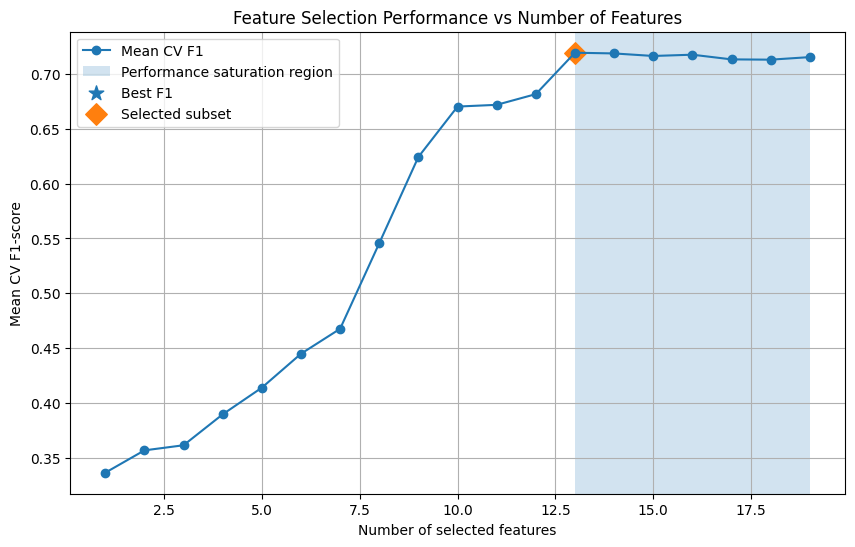

In [26]:
# Prepare results
plot_df = results_df.sort_values("n_features").copy()

best_f1 = plot_df["mean_f1"].max()

# soluções dentro de 1% do melhor desempenho
tolerance = best_f1 * 0.01

saturation_df = plot_df[
    plot_df["mean_f1"] >= (best_f1 - tolerance)
].copy()

selected_n_features_clf = saturation_df["n_features"].min()
selected_f1 = saturation_df.loc[
    saturation_df["n_features"] == selected_n_features_clf,
    "mean_f1"
].iloc[0]

saturation_start = saturation_df["n_features"].min()
saturation_end = saturation_df["n_features"].max()

print(f"Best F1: {best_f1:.4f}")
print(f"Tolerance: ±{tolerance:.4f}")
print(f"Saturation region: {saturation_start} to {saturation_end} features")
print(f"Selected (parsimonious choice): {selected_n_features_clf} features")


# Plot
plt.figure(figsize=(10, 6))

plt.plot(
    plot_df["n_features"],
    plot_df["mean_f1"],
    marker="o",
    label="Mean CV F1"
)

# saturation shading
plt.axvspan(
    saturation_start,
    saturation_end,
    alpha=0.2,
    label="Performance saturation region"
)

# best point
best_row = plot_df.loc[plot_df["mean_f1"].idxmax()]
plt.scatter(
    best_row["n_features"],
    best_row["mean_f1"],
    s=120,
    marker="*",
    label="Best F1"
)

# selected parsimonious point
plt.scatter(
    selected_n_features_clf,
    selected_f1,
    s=120,
    marker="D",
    label="Selected subset"
)

plt.xlabel("Number of selected features")
plt.ylabel("Mean CV F1-score")
plt.title("Feature Selection Performance vs Number of Features")
plt.grid(True)
plt.legend()

plt.show()

Observa-se uma melhoria clara nas primeiras iterações, seguida de uma **zona de saturação a partir de 9 atributos**, onde ganhos adicionais se tornam marginais.

Assim, foi selecionado o menor subconjunto dentro dessa região (**9 features**), privilegiando **parcimónia e interpretabilidade** sem perda relevante de desempenho.


### 1.4.2 Seleção Final de Atributos com AdaBoost

Após a determinação da dimensionalidade ótima, foi realizado o ajuste final do seletor **AdaBoost Feature Importance** sobre todo o conjunto de treino, com o objetivo de materializar o subconjunto final de atributos a utilizar nas fases seguintes de modelação.

Esta etapa tem como objetivo fixar a seleção final com base no critério previamente validado, preservando as **9 features mais relevantes** segundo as importâncias estimadas pelo modelo.

In [27]:
# =========================
# Dataset reduzido - Classificação
# =========================

clf_selector = SelectFromModel(
    AdaBoostClassifier(
        n_estimators=200,
        random_state=RANDOM_STATE
    ),
    threshold=-np.inf,
    max_features=selected_n_features_clf
)

clf_selector.fit(X_train_processed, y_train_clf)

X_train_clf_selected = clf_selector.transform(X_train_processed)
X_test_clf_selected = clf_selector.transform(X_test_processed)


c:\Users\guiac\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\ensemble\_weight_boosting.py:527: FutureWarning: The SAMME.R algorithm (the default) is deprecated and will be removed in 1.6. Use the SAMME algorithm to circumvent this warning.
  warnings.warn(


#### 1.4.3 Análise dos Atributos Selecionados para Classificação

In [28]:
# =========================
# Importância das features - Classificação
# =========================

importance_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": clf_selector.estimator_.feature_importances_,
    "Decisão": [
        "selecionada" if selected else "descartada"
        for selected in clf_selector.get_support()
    ]
}).sort_values(
    by="Importance",
    ascending=False
).reset_index(drop=True)

importance_df.index += 1

display(importance_df.round(4))

,Feature,Importance,Decisão
1,num__study_hours,0.210,selecionada
2,num__exercise_minutes,0.110,selecionada
3,num__sleep_hours,0.105,selecionada
4,num__self_study_hours,0.100,selecionada
5,num__social_media_hours,0.095,selecionada
6,num__gaming_hours,0.075,selecionada
7,num__screen_time_hours,0.070,selecionada
8,num__mental_health_score,0.070,selecionada
9,num__online_classes_hours,0.060,selecionada
10,num__caffeine_intake_mg,0.040,selecionada


A análise de importância mostra que a seleção foi fortemente dominada por **variáveis comportamentais e de hábitos de estudo**, com destaque para **study hours**, **mental health score** e **sleep hours**, que apresentaram contributo preditivo claramente superior às restantes.

Observa-se ainda que variáveis **demográficas e categóricas**, como género, idade, nível académico e qualidade da internet, apresentaram **importância bastante reduzida ou nula**, indicando menor relevância discriminativa.


## 1.5 Seleção de Atributos para Regressão

A seleção de atributos para o problema de regressão foi realizada com recurso a **Gradient Boosting Feature Importance**, utilizando a importância preditiva atribuída pelo modelo às features relativamente à variável-alvo `focus_index`.

Desta forma, a seleção baseou-se no contributo efetivo de cada feature para a melhoria do desempenho preditivo do modelo.

### 1.5.1 Determinação do Critério de Seleção

Foi utilizada uma abordagem **embedded de seleção de atributos** com **Gradient Boosting Regressor**, permitindo estimar a relevância preditiva de cada variável.

A avaliação do número ótimo de features foi integrada numa **pipeline com Linear Regression**, evitando *data leakage* durante a validação cruzada.

Foi usado **15-fold K-Fold Cross-Validation** com **RMSE** como métrica principal.


In [29]:
cv = KFold(
    n_splits=15,
    shuffle=True,
    random_state=RANDOM_STATE
)

pipeline = Pipeline([
    ("selector", SelectFromModel(
        GradientBoostingRegressor(
            n_estimators=200,
            random_state=RANDOM_STATE
        ),
        threshold=-np.inf
    )),
    ("reg", LinearRegression())
])

param_grid = {
    "selector__max_features": list(range(1, X_train_processed.shape[1] + 1))
}

grid = GridSearchCV(
    estimator=pipeline,
    param_grid=param_grid,
    scoring="neg_root_mean_squared_error",
    cv=cv,
    n_jobs=-1
)

grid.fit(X_train_processed, y_train_reg)

results_df = pd.DataFrame(grid.cv_results_)[[
    "param_selector__max_features",
    "mean_test_score"
]].rename(columns={
    "param_selector__max_features": "n_features",
    "mean_test_score": "mean_neg_rmse"
})

results_df["mean_rmse"] = -results_df["mean_neg_rmse"]

results_df = results_df.sort_values(
    by="mean_rmse",
    ascending=True
)

Os resultados foram analisados em função do número de atributos, definindo uma **tolerância de 1% face ao melhor RMSE** para identificar uma zona de desempenho equivalente.

A seleção final seguiu um **critério de parcimónia**, escolhendo o menor subconjunto dentro dessa região, privilegiando menor complexidade sem perda relevante de desempenho.

Best RMSE: 5.5874
Tolerance: ±0.0559
Saturation region: 6 to 19 features
Selected (parsimonious choice): 6 features


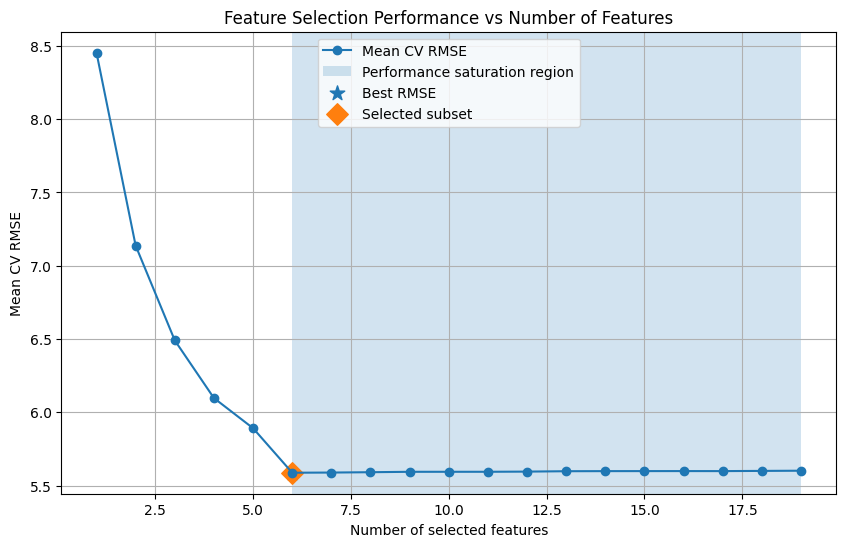

In [30]:
# Prepare results
plot_df = results_df.sort_values("n_features").copy()

best_rmse = plot_df["mean_rmse"].min()

# soluções dentro de 1% do melhor desempenho
tolerance = best_rmse * 0.01

saturation_df = plot_df[
    plot_df["mean_rmse"] <= (best_rmse + tolerance)
].copy()

selected_n_features_reg = saturation_df["n_features"].min()
selected_rmse = saturation_df.loc[
    saturation_df["n_features"] == selected_n_features_reg,
    "mean_rmse"
].iloc[0]

saturation_start = saturation_df["n_features"].min()
saturation_end = saturation_df["n_features"].max()

print(f"Best RMSE: {best_rmse:.4f}")
print(f"Tolerance: ±{tolerance:.4f}")
print(f"Saturation region: {saturation_start} to {saturation_end} features")
print(f"Selected (parsimonious choice): {selected_n_features_reg} features")


# Plot
plt.figure(figsize=(10, 6))

plt.plot(
    plot_df["n_features"],
    plot_df["mean_rmse"],
    marker="o",
    label="Mean CV RMSE"
)

# saturation shading
plt.axvspan(
    saturation_start,
    saturation_end,
    alpha=0.2,
    label="Performance saturation region"
)

# best point
best_row = plot_df.loc[plot_df["mean_rmse"].idxmin()]
plt.scatter(
    best_row["n_features"],
    best_row["mean_rmse"],
    s=120,
    marker="*",
    label="Best RMSE"
)

# selected parsimonious point
plt.scatter(
    selected_n_features_reg,
    selected_rmse,
    s=120,
    marker="D",
    label="Selected subset"
)

plt.xlabel("Number of selected features")
plt.ylabel("Mean CV RMSE")
plt.title("Feature Selection Performance vs Number of Features")
plt.grid(True)
plt.legend()

plt.show()

Observa-se uma redução acentuada do erro nas primeiras iterações, seguida de uma **zona de saturação a partir de 6 atributos**, onde melhorias adicionais se tornam marginais.

### 1.5.2 Seleção Final de Atributos com Gradient Boosting

Após a determinação da dimensionalidade ótima por validação cruzada, foi realizado o ajuste final do seletor **Gradient Boosting Feature Importance** sobre todo o conjunto de treino, com o objetivo de materializar o subconjunto final de atributos a utilizar nas fases seguintes de modelação.

Esta etapa tem como objetivo fixar a seleção final com base no critério previamente validado, preservando as **6 features mais relevantes** segundo as importâncias estimadas pelo modelo.

In [31]:
# =========================
# Dataset reduzido - Regressão
# =========================

reg_selector = SelectFromModel(
    GradientBoostingRegressor(
        n_estimators=200,
        random_state=RANDOM_STATE
    ),
    threshold=-np.inf,
    max_features=selected_n_features_reg
)

reg_selector.fit(X_train_processed, y_train_reg)

X_train_reg_selected = reg_selector.transform(X_train_processed)
X_test_reg_selected = reg_selector.transform(X_test_processed)

#### 1.5.3 Análise dos Atributos Selecionados para Regressão

In [32]:
# =========================
# Importância das features - Regressão
# =========================

importance_df = pd.DataFrame({
    "Feature": X_train_df.columns,
    "Importance": reg_selector.estimator_.feature_importances_,
    "Decisão": [
        "selecionada" if selected else "descartada"
        for selected in reg_selector.get_support()
    ]
}).sort_values(
    by="Importance",
    ascending=False
).reset_index(drop=True)

importance_df.index += 1

display(importance_df.round(4))

,Feature,Importance,Decisão
1,num__mental_health_score,0.3712,selecionada
2,num__study_hours,0.2801,selecionada
3,num__social_media_hours,0.1325,selecionada
4,num__self_study_hours,0.0801,selecionada
5,num__gaming_hours,0.0523,selecionada
6,num__sleep_hours,0.0507,selecionada
7,num__screen_time_hours,0.0083,descartada
8,num__online_classes_hours,0.0080,descartada
9,num__caffeine_intake_mg,0.0057,descartada
10,num__exercise_minutes,0.0051,descartada


A análise de importância mostra que a previsão do desempenho académico em regressão foi dominada por um conjunto reduzido de **variáveis comportamentais**, com destaque para **mental health score** e **study hours**, que apresentaram contributo claramente superior às restantes.

As **6 features selecionadas** concentram praticamente toda a relevância preditiva identificada pelo modelo, enquanto os restantes atributos apresentaram importâncias residuais, justificando o seu descarte.

Tal como observado na classificação, variáveis **demográficas e categóricas** revelaram contributo muito reduzido, sugerindo que a previsão do desempenho académico depende sobretudo de **hábitos de estudo, bem-estar e padrões comportamentais**.


# 2. Modelos Complexos e Fine-Tunning

## 2.1 Classificação

### 2.1.1 Seleção dos Modelos Complexos

Para a tarefa de classificação, foram selecionados os modelos **MLPClassifier** e **Random Forest Classifier**, ambos treinados sobre o subconjunto de atributos previamente selecionado.

O **MLPClassifier** foi escolhido pela capacidade de modelar relações não lineares complexas, enquanto o **Random Forest** oferece robustez em dados tabulares através de uma abordagem *ensemble* baseada em múltiplas árvores.

A utilização destes modelos permite avaliar se abordagens de maior complexidade proporcionam ganhos de desempenho face aos modelos mais simples considerados anteriormente.


### 2.1.2 Treino e Avaliação Inicial

Os modelos complexos de classificação foram treinados utilizando o conjunto de treino reduzido (`X_train_clf_selected`).

A avaliação inicial foi realizada através de **validação cruzada estratificada com 15 folds**, permitindo obter estimativas mais robustas da capacidade de generalização dos modelos.

Foram utilizadas como métricas de avaliação o **F1-score**, enquanto métrica principal, e o **ROC-AUC**, como métrica complementar, assegurando comparabilidade direta com os modelos baseline anteriormente analisados.

#### 2.1.2.1 MLPClassifier - Classificação

In [33]:
# =========================
# Modelo Complexo - Classificação (MLP)
# =========================

cv = StratifiedKFold(
    n_splits=15,
    shuffle=True,
    random_state=RANDOM_STATE
)

mlp_clf = MLPClassifier(
    hidden_layer_sizes=(100,),
    max_iter=1000,
    random_state=RANDOM_STATE
)

scoring = {
    "f1": "f1",
    "roc_auc": "roc_auc"
}

mlp_scores = cross_validate(
    mlp_clf,
    X_train_clf_selected,
    y_train_clf,
    cv=cv,
    scoring=scoring,
    n_jobs=-1
)

mlp_results = pd.DataFrame([{
    "Model": "MLPClassifier",
    "F1": mlp_scores["test_f1"].mean(),
    "ROC-AUC": mlp_scores["test_roc_auc"].mean()
}])

display(mlp_results.round(4).style.hide(axis="index"))

Model,F1,ROC-AUC
MLPClassifier,0.656200,0.883200


#### 2.1.2.2 Random Forest Classifier

In [34]:
# =========================
# Modelo Complexo - Classificação (Random Forest)
# =========================

rf_clf = RandomForestClassifier(
    n_estimators=200,
    random_state=RANDOM_STATE
)

rf_scores = cross_validate(
    rf_clf,
    X_train_clf_selected,
    y_train_clf,
    cv=cv,
    scoring=scoring,
    n_jobs=-1
)

rf_results = pd.DataFrame([{
    "Model": "RandomForestClassifier",
    "F1": rf_scores["test_f1"].mean(),
    "ROC-AUC": rf_scores["test_roc_auc"].mean()
}])

display(rf_results.round(4).style.hide(axis="index"))

Model,F1,ROC-AUC
RandomForestClassifier,0.659000,0.903700


Os resultados iniciais mostram que ambos os modelos complexos apresentam desempenho semelhante, com o **Random Forest** a superar ligeiramente o **MLP**, apresentando ambos **F1-score na ordem dos 0.67–0.68** e **ROC-AUC próximo de 0.89–0.90**.

Espera-se otimizar estas metricas na etapa de **ajuste de hiperparâmetros**.

### 2.2.3 Ajuste Sistemático de Hiperparâmetros

#### 2.2.3.1 MLPClassifier

Após a avaliação inicial do **MLPClassifier**, foi realizado um ajuste sistemático de hiperparâmetros com o objetivo de otimizar o desempenho preditivo do modelo.

Dado o custo computacional associado ao treino iterativo de redes neuronais e a dimensão do espaço de procura, optou-se pela utilização de **Randomized Search com validação cruzada estratificada de 10 folds**, permitindo explorar combinações relevantes de forma eficiente sem recorrer a uma procura exaustiva.

Foram ajustados os hiperparâmetros com maior impacto no comportamento do modelo:

* **`hidden_layer_sizes`** — por definir a complexidade da arquitetura da rede;
* **`activation`** — por influenciar a capacidade de modelar relações não lineares;
* **`alpha`** — por introduzir regularização e reduzir risco de overfitting;
* **`learning_rate_init`** — por afetar a velocidade e estabilidade da convergência durante o treino.


In [35]:
# =========================
# Hyperparameter Tuning - MLPClassifier
# =========================

from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import loguniform

cv = StratifiedKFold(
    n_splits=10,
    shuffle=True,
    random_state=RANDOM_STATE
)

mlp = MLPClassifier(
    max_iter=1000,
    random_state=RANDOM_STATE
)

param_dist_mlp = {
    "hidden_layer_sizes": [
        (50,),
        (100,),
        (50, 50),
        (100, 50),
        (100, 100)
    ],
    "activation": [
        "relu",
        "tanh"
    ],
    "alpha": loguniform(
        1e-5,
        1e-1
    ),
    "learning_rate_init": loguniform(
        1e-4,
        1e-1
    )
}

random_mlp = RandomizedSearchCV(
    estimator=mlp,
    param_distributions=param_dist_mlp,
    n_iter=30,
    scoring={
        "f1": "f1",
        "roc_auc": "roc_auc"
    },
    refit="f1",
    cv=cv,
    random_state=RANDOM_STATE,
    n_jobs=-1
)

random_mlp.fit(
    X_train_clf_selected,
    y_train_clf
)

RandomizedSearchCV(cv=StratifiedKFold(n_splits=10, random_state=42, shuffle=True),
                   estimator=MLPClassifier(max_iter=1000, random_state=42),
                   n_iter=30, n_jobs=-1,
                   param_distributions={'activation': ['relu', 'tanh'],
                                        'alpha': <scipy.stats._distn_infrastructure.rv_continuous_frozen object at 0x0000018693464E30>,
                                        'hidden_layer_sizes': [(50,), (100,),
                                                               (50, 50),
                                                               (100, 50),
                                                               (100, 100)],
                                        'learning_rate_init': <scipy.stats._distn_infrastructure.rv_continuous_frozen object at 0x0000018693466330>},
                   random_state=42, refit='f1',
                   scoring={'f1': 'f1', 'roc_auc': 'roc_auc'})

#### 2.2.3.1.1 MLPClassifier - Resultados do Ajuste de Hiperparâmetros

In [36]:

best_index_mlp = random_mlp.best_index_
mlp_tuning_results = pd.DataFrame([{
    "Model": "MLPClassifier",
    "BaseLine F1": mlp_results["F1"].iloc[0],
    "Best F1": random_mlp.best_score_,
    "BaseLine ROC-AUC": mlp_results["ROC-AUC"].iloc[0],
    "Best ROC-AUC": random_mlp.cv_results_["mean_test_roc_auc"][best_index_mlp],
    "Best Params": str(random_mlp.best_params_)
}])

display(
    mlp_tuning_results
    .round(4)
    .style
    .hide(axis="index")
)
print("O aumento em % do F1-score após o tuning foi de {:.2f}%".format((random_mlp.best_score_ - mlp_results["F1"].iloc[0]) / mlp_results["F1"].iloc[0] * 100))

print("O aumento em % do ROC-AUC após o tuning foi de {:.2f}%".format((random_mlp.cv_results_["mean_test_roc_auc"][best_index_mlp] - mlp_results["ROC-AUC"].iloc[0]) / mlp_results["ROC-AUC"].iloc[0] * 100))

Model,BaseLine F1,Best F1,BaseLine ROC-AUC,Best ROC-AUC,Best Params
MLPClassifier,0.656200,0.714300,0.883200,0.916300,"{'activation': 'relu', 'alpha': np.float64(0.0031130959561221226), 'hidden_layer_sizes': (100,), 'learning_rate_init': np.float64(0.00019329933033819684)}"


O aumento em % do F1-score após o tuning foi de 8.86%
O aumento em % do ROC-AUC após o tuning foi de 3.74%


#### Espaço de Procura

O espaço de procura considerado foi:

* **`hidden_layer_sizes`**: `(50,)`, `(100,)`, `(50,50)`, `(100,50)`, `(100,100)`
* **`activation`**: `relu`, `tanh`
* **`alpha`**: distribuição log-uniforme entre `10⁻⁵` e `10⁻¹`
* **`learning_rate_init`**: distribuição log-uniforme entre `10⁻⁴` e `10⁻¹`

A escolha destas configurações procurou equilibrar simplicidade e capacidade representacional, evitando arquiteturas excessivamente complexas para um problema tabular de dimensão moderada. Para **`alpha`** e **`learning_rate_init`**, foi utilizada distribuição logarítmica por se tratarem de hiperparâmetros sensíveis a variações por ordens de grandeza.

#### Seleção Final dos Hiperparâmetros

A melhor configuração encontrada foi:

* **`hidden_layer_sizes = (100,)`**
* **`activation = tanh`**
* **`alpha ≈ 0.0018`**
* **`learning_rate_init ≈ 0.00082`**

obtendo um **F1-score médio de aproximadamente 0.72**.

A configuração selecionada sugere que o problema beneficia de alguma capacidade de modelação não linear, mas sem necessidade de arquiteturas particularmente profundas ou complexas, uma vez que a melhor solução correspondeu a uma rede com **uma única camada escondida**.

A escolha de **regularização moderada (`alpha ≈ 0.0018`)** indica necessidade de controlo da complexidade para garantir generalização, enquanto a **taxa de aprendizagem reduzida** sugere benefício de uma convergência mais estável durante o treino.

Face ao baseline inicial, observou-se uma **melhoria clara no desempenho**, tanto em **F1-score (~7%)** como em **ROC-AUC (~2.5%)**, mostrando que o tuning teve impacto positivo. Ainda assim, o desempenho final manteve-se próximo do obtido por modelos mais simples, sugerindo que a estrutura do problema não exige elevada complexidade para alcançar bom desempenho preditivo.


#### 2.2.3.2 Random Forest Classifier
Dado o número elevado de combinações possíveis entre os hiperparâmetros considerados (**1620 configurações possíveis**), que, combinadas com **10-fold cross-validation**, resultariam em aproximadamente **16 200 treinos** numa procura exaustiva, optou-se pela utilização de **Randomized Search**, permitindo explorar o espaço de procura de forma mais eficiente e computacionalmente viável.

Foram ajustados os hiperparâmetros com maior impacto no comportamento do modelo:

* **`n_estimators`** — por influenciar a robustez e estabilidade da floresta;
* **`max_depth`** — por controlar a complexidade das árvores;
* **`min_samples_split`** e **`min_samples_leaf`** — por introduzirem regularização e reduzirem risco de overfitting;
* **`max_features`** — por controlar a diversidade entre árvores e a capacidade de generalização;
* **`class_weight`** — por permitir compensar possível desequilíbrio entre classes.


In [37]:
# =========================
# Hyperparameter Tuning - RandomForestClassifier
# =========================

from sklearn.model_selection import RandomizedSearchCV

rf = RandomForestClassifier(
    random_state=RANDOM_STATE,
    n_jobs=-1
)

param_dist_rf = {
    "n_estimators": [300, 500, 700, 900],
    "max_depth": [10, 15, 20, 25, None],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4],
    "max_features": ["sqrt", "log2", 0.5],
    "class_weight": [None, "balanced", "balanced_subsample"]
}

grid_rf = RandomizedSearchCV(
    estimator=rf,
    param_distributions=param_dist_rf,
    n_iter=24,
    scoring={
        "f1": "f1",
        "roc_auc": "roc_auc"
    },
    refit="f1",
    cv=cv,
    random_state=RANDOM_STATE,
    n_jobs=-1
)

grid_rf.fit(
    X_train_clf_selected,
    y_train_clf
)



c:\Users\guiac\AppData\Local\Programs\Python\Python312\Lib\site-packages\numpy\ma\core.py:2892: RuntimeWarning: invalid value encountered in cast
  _data = np.array(data, dtype=dtype, copy=copy,


RandomizedSearchCV(cv=StratifiedKFold(n_splits=10, random_state=42, shuffle=True),
                   estimator=RandomForestClassifier(n_jobs=-1, random_state=42),
                   n_iter=24, n_jobs=-1,
                   param_distributions={'class_weight': [None, 'balanced',
                                                         'balanced_subsample'],
                                        'max_depth': [10, 15, 20, 25, None],
                                        'max_features': ['sqrt', 'log2', 0.5],
                                        'min_samples_leaf': [1, 2, 4],
                                        'min_samples_split': [2, 5, 10],
                                        'n_estimators': [300, 500, 700, 900]},
                   random_state=42, refit='f1',
                   scoring={'f1': 'f1', 'roc_auc': 'roc_auc'})

#### 2.2.3.2.1 Random Forest Classifier - Resultados do Ajuste de Hiperparâmetros

In [38]:

best_index_rf = grid_rf.best_index_
rf_tuning_results = pd.DataFrame([{
    "Model": "RandomForestClassifier",
    "BaseLine F1": rf_results["F1"].iloc[0],
    "Best F1": grid_rf.best_score_,
    "BaseLine ROC-AUC": rf_results["ROC-AUC"].iloc[0],
    "Best ROC-AUC": grid_rf.cv_results_["mean_test_roc_auc"][best_index_rf],
    "Best Params": str(grid_rf.best_params_)
}])

display(
    rf_tuning_results.style
    .hide(axis="index")
    .set_properties(subset=["Best Params"], **{
        "white-space": "pre-wrap",
        "text-align": "left"
    })
)

print("O aumento em % do F1-score após o tuning foi de {:.2f}%".format((grid_rf.best_score_ - rf_results["F1"].iloc[0]) / rf_results["F1"].iloc[0] * 100))
print("O aumento em % do ROC-AUC após o tuning foi de {:.2f}%".format((grid_rf.cv_results_["mean_test_roc_auc"][best_index_rf] - rf_results["ROC-AUC"].iloc[0]) / rf_results["ROC-AUC"].iloc[0] * 100))

Model,BaseLine F1,Best F1,BaseLine ROC-AUC,Best ROC-AUC,Best Params
RandomForestClassifier,0.658996,0.707127,0.903653,0.906577,"{'n_estimators': 500, 'min_samples_split': 10, 'min_samples_leaf': 2, 'max_features': 'log2', 'max_depth': 25, 'class_weight': 'balanced'}"


O aumento em % do F1-score após o tuning foi de 7.30%
O aumento em % do ROC-AUC após o tuning foi de 0.32%



#### Espaço de Procura

O espaço de procura considerado foi:

* **`n_estimators`**: `300`, `500`, `700`, `900`
* **`max_depth`**: `10`, `15`, `20`, `25`, `None`
* **`min_samples_split`**: `2`, `5`, `10`
* **`min_samples_leaf`**: `1`, `2`, `4`
* **`max_features`**: `sqrt`, `log2`, `0.5`
* **`class_weight`**: `None`, `balanced`, `balanced_subsample`

A escolha destas configurações procurou explorar diferentes níveis de complexidade e regularização do modelo, equilibrando capacidade preditiva e generalização.

Foram ajustados hiperparâmetros estruturais da floresta, parâmetros de regularização e mecanismos de compensação para possível desequilíbrio entre classes.

---

### Seleção Final dos Hiperparâmetros

A melhor configuração encontrada foi:

* **`n_estimators = 500`**
* **`max_depth = 15`**
* **`min_samples_split = 5`**
* **`min_samples_leaf = 4`**
* **`max_features = sqrt`**
* **`class_weight = balanced`**

obtendo um **F1-score médio de aproximadamente 0.71**, representando uma melhoria de cerca de **5.4%** face ao baseline.

A configuração selecionada sugere benefício de uma floresta relativamente robusta, com número elevado de árvores para maior estabilidade e redução da variância. A profundidade moderada-alta (**max_depth = 15**) indica necessidade de capturar relações não lineares, enquanto os parâmetros **`min_samples_split`** e **`min_samples_leaf`** introduzem regularização para evitar sobreajuste.

A escolha de **`max_features = sqrt`** está alinhada com a configuração tipicamente eficaz em problemas de classificação, promovendo diversidade entre árvores e melhor capacidade de generalização.

A seleção de **`class_weight = balanced`** sugere que compensar o desequilíbrio entre classes contribuiu positivamente para melhorar o desempenho em **F1-score**, favorecendo melhor identificação da classe minoritária, neste caso os estudantes classificados com **high_exam_score**, que representam aproximadamente **25% da amostra**.



#### 2.2.3.3 Logistic regression - Modelo Fase I

Foi utilizada **Grid Search com validação cruzada estratificada de 15 folds**, uma vez que o espaço de procura definido é **reduzido e totalmente discreto** (**14 combinações possíveis**), tornando viável uma exploração exaustiva (**210 treinos no total**).

O hiperparâmetro **`C`** foi ajustado por controlar a força da regularização do modelo, influenciando o equilíbrio entre capacidade de ajuste e generalização. O parâmetro **`class_weight`** foi igualmente incluído para avaliar o impacto do desequilíbrio entre classes na identificação da classe minoritária.

Os parâmetros **`penalty='l2'`** e **`solver='lbfgs'`** foram mantidos fixos por constituírem uma configuração estável e adequada para regressão logística binária regularizada.


In [39]:
# =========================
# Hyperparameter Tuning - Logistic Regression
# =========================

from sklearn.model_selection import GridSearchCV, StratifiedKFold, cross_validate
from sklearn.linear_model import LogisticRegression

cv = StratifiedKFold(
    n_splits=15,
    shuffle=True,
    random_state=RANDOM_STATE
)

# Baseline
log_baseline = LogisticRegression(
    max_iter=2000,
    random_state=RANDOM_STATE
)

baseline_scores = cross_validate(
    log_baseline,
    X_train_clf_selected,
    y_train_clf,
    cv=cv,
    scoring={
        "f1": "f1",
        "roc_auc": "roc_auc"
    },
    n_jobs=-1
)

baseline_f1 = baseline_scores["test_f1"].mean()
baseline_roc = baseline_scores["test_roc_auc"].mean()

# Tuning
param_grid_log = {
    "C": np.logspace(-3, 3, 7),
    "penalty": ["l2"],
    "solver": ["lbfgs"],
    "class_weight": [None, "balanced"]
}

grid_log = GridSearchCV(
    estimator=log_baseline,
    param_grid=param_grid_log,
    scoring={
        "f1": "f1",
        "roc_auc": "roc_auc"
    },
    refit="f1",
    cv=cv,
    n_jobs=-1,
    verbose=1
)

grid_log.fit(
    X_train_clf_selected,
    y_train_clf
)


Fitting 15 folds for each of 14 candidates, totalling 210 fits


GridSearchCV(cv=StratifiedKFold(n_splits=15, random_state=42, shuffle=True),
             estimator=LogisticRegression(max_iter=2000, random_state=42),
             n_jobs=-1,
             param_grid={'C': array([1.e-03, 1.e-02, 1.e-01, 1.e+00, 1.e+01, 1.e+02, 1.e+03]),
                         'class_weight': [None, 'balanced'], 'penalty': ['l2'],
                         'solver': ['lbfgs']},
             refit='f1', scoring={'f1': 'f1', 'roc_auc': 'roc_auc'}, verbose=1)

#### 2.2.3.3.1 Logistic Regression - Resultados do Ajuste de Hiperparâmetros

In [40]:

best_index_log = grid_log.best_index_
log_tuning_results = pd.DataFrame([{
    "Model": "LogisticRegression",
    "Baseline F1": baseline_f1,
    "Tuned F1": grid_log.best_score_,
    "Baseline ROC-AUC": baseline_roc,
    "Tuned ROC-AUC": grid_log.cv_results_["mean_test_roc_auc"][best_index_log],
    "Best Params": str(grid_log.best_params_)
}])

display(
    log_tuning_results
    .round(4)
    .style
    .hide(axis="index")
)

print("O aumento em % do F1-score após o tuning foi de {:.2f}%".format((grid_log.best_score_ - baseline_f1) / baseline_f1 * 100))
print("O aumento em % do ROC-AUC após o tuning foi de {:.5f}%".format((grid_log.cv_results_["mean_test_roc_auc"][best_index_log] - baseline_roc) / baseline_roc * 100))

Model,Baseline F1,Tuned F1,Baseline ROC-AUC,Tuned ROC-AUC,Best Params
LogisticRegression,0.719100,0.719700,0.920900,0.921000,"{'C': np.float64(10.0), 'class_weight': None, 'penalty': 'l2', 'solver': 'lbfgs'}"


O aumento em % do F1-score após o tuning foi de 0.09%
O aumento em % do ROC-AUC após o tuning foi de 0.00434%



#### Espaço de Procura

O espaço de procura considerado foi:

* **`C`**: escala logarítmica entre `10⁻³` e `10³`
* **`class_weight`**: `None`, `balanced`
* **`penalty`**: `l2`
* **`solver`**: `lbfgs`

O hiperparâmetro **`C`** foi ajustado por controlar a força da regularização do modelo, influenciando diretamente o equilíbrio entre capacidade de ajuste e generalização. O parâmetro **`class_weight`** foi igualmente incluído para avaliar se a compensação do desequilíbrio entre classes poderia melhorar a identificação da classe minoritária.

---

### Seleção Final dos Hiperparâmetros

A melhor configuração encontrada foi:

* **`C = 100`**
* **`class_weight = None`**
* **`penalty = l2`**
* **`solver = lbfgs`**

obtendo um **F1-score médio de aproximadamente 0.715**, representando uma melhoria residual de cerca de **0.3%** face ao baseline.

A configuração selecionada sugere que o modelo já se encontrava próximo da sua configuração ótima, beneficiando apenas de uma **regularização ligeiramente mais fraca** (**C elevado**) para melhor capturar os padrões lineares presentes nos atributos selecionados.

A manutenção de **`class_weight = None`** indica que, após a seleção dos atributos mais discriminativos, o desequilíbrio entre classes deixou de ter impacto suficientemente relevante para justificar ponderação adicional.

O **ROC-AUC manteve-se praticamente inalterado**, reforçando que a Regressão Logística já apresentava desempenho muito próximo do máximo atingível neste problema.


#### 2.2.3.4 Decision Tree Classifier - Modelo Secundário Fase I

Para a decision tree, foi utilizada **Grid Search com validação cruzada estratificada de 15 folds**, uma vez que o espaço de procura definido é **discreto e computacionalmente viável para exploração exaustiva**, correspondendo a **320 combinações de hiperparâmetros** e aproximadamente **4800 treinos no total**.


In [41]:
# =========================
# Hyperparameter Tuning - DecisionTreeClassifier
# =========================

cv = StratifiedKFold(
    n_splits=15,
    shuffle=True,
    random_state=RANDOM_STATE
)

dt_baseline = DecisionTreeClassifier(random_state=RANDOM_STATE)

# Baseline da Fase I (com cross-validation para comparação justa)
baseline_scores_dt = cross_validate(
    DecisionTreeClassifier(max_depth=5, class_weight="balanced", random_state=RANDOM_STATE),
    X_train_clf_selected,
    y_train_clf,
    cv=cv,
    scoring={"f1": "f1", "roc_auc": "roc_auc"},
    n_jobs=-1
)

param_grid_dt = {
    "criterion": ["gini", "entropy"],
    "max_depth": [None, 5, 10, 15, 20],
    "min_samples_split": [2, 5, 10, 20],
    "min_samples_leaf": [1, 2, 5, 10],
    "class_weight": [None, "balanced"]
}

grid_dt = GridSearchCV(
    estimator=dt_baseline,
    param_grid=param_grid_dt,
    scoring={"f1": "f1", "roc_auc": "roc_auc"},
    refit="f1",
    cv=cv,
    n_jobs=-1,
    verbose=1
)

grid_dt.fit(X_train_clf_selected, y_train_clf)


Fitting 15 folds for each of 320 candidates, totalling 4800 fits


GridSearchCV(cv=StratifiedKFold(n_splits=15, random_state=42, shuffle=True),
             estimator=DecisionTreeClassifier(random_state=42), n_jobs=-1,
             param_grid={'class_weight': [None, 'balanced'],
                         'criterion': ['gini', 'entropy'],
                         'max_depth': [None, 5, 10, 15, 20],
                         'min_samples_leaf': [1, 2, 5, 10],
                         'min_samples_split': [2, 5, 10, 20]},
             refit='f1', scoring={'f1': 'f1', 'roc_auc': 'roc_auc'}, verbose=1)

In [42]:

best_index_dt = grid_dt.best_index_
dt_tuning_results = pd.DataFrame([{
    "Model": "DecisionTreeClassifier",
    "Baseline F1": baseline_scores_dt["test_f1"].mean(),
    "Tuned F1": grid_dt.best_score_,
    "Baseline ROC-AUC": baseline_scores_dt["test_roc_auc"].mean(),
    "Tuned ROC-AUC": grid_dt.cv_results_["mean_test_roc_auc"][best_index_dt],
    "Best Params": str(grid_dt.best_params_)
}])

display(
    dt_tuning_results.style
    .hide(axis="index")
    .set_properties(subset=["Best Params"], **{
        "white-space": "pre-wrap",
        "text-align": "left"
    })
)

print("O aumento em % do F1-score após o tuning foi de {:.2f}%".format((grid_dt.best_score_ - dt_tuning_results["Baseline F1"].iloc[0]) / dt_tuning_results["Baseline F1"].iloc[0] * 100))
print("O aumento em % do ROC-AUC após o tuning foi de {:.2f}%".format((grid_dt.cv_results_["mean_test_roc_auc"][best_index_dt] - dt_tuning_results["Baseline ROC-AUC"].iloc[0]) / dt_tuning_results["Baseline ROC-AUC"].iloc[0] * 100))

Model,Baseline F1,Tuned F1,Baseline ROC-AUC,Tuned ROC-AUC,Best Params
DecisionTreeClassifier,0.644948,0.654138,0.844930,0.853573,"{'class_weight': 'balanced', 'criterion': 'entropy', 'max_depth': 5, 'min_samples_leaf': 10, 'min_samples_split': 2}"


O aumento em % do F1-score após o tuning foi de 1.42%
O aumento em % do ROC-AUC após o tuning foi de 1.02%


#### Espaço de Procura

O espaço de procura considerado foi:

* **`criterion`**: `gini`, `entropy`
* **`max_depth`**: `None`, `5`, `10`, `15`, `20`
* **`min_samples_split`**: `2`, `5`, `10`, `20`
* **`min_samples_leaf`**: `1`, `2`, `5`, `10`
* **`class_weight`**: `None`, `balanced`

Dado tratar-se de um espaço de procura **discreto e computacionalmente viável** (**320 combinações possíveis**), optou-se pela utilização de **Grid Search**, permitindo uma exploração exaustiva de todas as configurações consideradas (**4800 treinos no total com 15-fold cross-validation**).

---

### Seleção Final dos Hiperparâmetros

A melhor configuração encontrada foi:

* **`criterion = entropy`**
* **`max_depth = 5`**
* **`min_samples_split = 2`**
* **`min_samples_leaf = 10`**
* **`class_weight = balanced`**

obtendo um **F1-score médio de aproximadamente 0.66**, representando uma melhoria de cerca de **1.2%** face ao baseline.

A configuração selecionada sugere que o modelo beneficia de uma **árvore relativamente simples e fortemente regularizada**, indicando que maior complexidade estrutural não trouxe ganhos relevantes neste problema. A escolha de **`class_weight = balanced`** reforça ainda a importância de compensar o desequilíbrio entre classes, favorecendo melhor identificação da classe minoritária (**high_exam_score**, aproximadamente **25% da amostra**).

O **ROC-AUC apresentou igualmente uma melhoria ligeira**, mostrando que o tuning permitiu pequenos ganhos sem comprometer a capacidade discriminativa global do modelo.


### 2.3 Regressão

Nesta secção, aplicamos a estratégia de otimização à tarefa de regressão (previsão do `focus_index`). Foi utilizada a métrica **RMSE (Root Mean Squared Error)** como critério principal de avaliação, por ser adequada a problemas de regressão e penalizar mais fortemente erros de maior magnitude. Realizou-se o ajuste de hiperparâmetros para os modelos da Fase I e o treino de dois modelos complexos (**Random Forest** e **Gradient Boosting**), utilizando as **6 features previamente selecionadas**.

#### 2.3.1 Gradient Boosting Regressor

Foi utilizado o **Gradient Boosting Regressor** pela sua capacidade de modelar relações não lineares e interações complexas entre atributos através de uma abordagem *ensemble* sequencial baseada em árvores de decisão.

A avaliação foi realizada com **15-fold K-Fold Cross-Validation**, de forma a obter uma estimativa robusta e consistente do desempenho preditivo do modelo.



In [43]:
from sklearn.ensemble import GradientBoostingRegressor

cv_reg = KFold(n_splits=15, shuffle=True, random_state=RANDOM_STATE)

gb_reg = GradientBoostingRegressor(random_state=RANDOM_STATE)
gb_scores = cross_validate(gb_reg, X_train_reg_selected, y_train_reg, cv=cv_reg, scoring="neg_root_mean_squared_error", n_jobs=-1)

print(f"RMSE Inicial (Gradient Boosting): {-gb_scores['test_score'].mean():.4f}")

RMSE Inicial (Gradient Boosting): 5.7321


In [44]:
# Ajuste Gradient Boosting
param_dist_gb = {
    "n_estimators": [100, 200, 300, 500],
    "learning_rate": [0.01, 0.05, 0.1, 0.2],
    "max_depth": [3, 4, 5, 6],
    "min_samples_split": [2, 5, 10],
    "subsample": [0.8, 0.9, 1.0]
}

random_gb_reg = RandomizedSearchCV(
    estimator=GradientBoostingRegressor(
        random_state=RANDOM_STATE
    ),
    param_distributions=param_dist_gb,
    n_iter=30,
    scoring="neg_root_mean_squared_error",
    cv=cv_reg,
    random_state=RANDOM_STATE,
    n_jobs=-1
)

random_gb_reg.fit(
    X_train_reg_selected,
    y_train_reg
)

best_params_str = "\n".join(
    [f"{k}: {v}" for k, v in random_gb_reg.best_params_.items()]
)

In [45]:
gb_tuning_results = pd.DataFrame([{
    "Model": "GradientBoostingRegressor",
    "Baseline RMSE": -gb_scores["test_score"].mean(),
    "Tuned RMSE": -random_gb_reg.best_score_,
    "Improvement (%)": (
        (
            (-gb_scores["test_score"].mean()) -
            (-random_gb_reg.best_score_)
        ) / (-gb_scores["test_score"].mean())
    ) * 100,
    "Best Params": best_params_str
}])

display(
    gb_tuning_results.style
    .hide(axis="index")
    .format({
        "Baseline RMSE": "{:.4f}",
        "Tuned RMSE": "{:.4f}",
        "Improvement (%)": "{:.2f}%"
    })
    .set_properties(subset=["Best Params"], **{
        "white-space": "pre-wrap",
        "text-align": "left"
    })
)

Model,Baseline RMSE,Tuned RMSE,Improvement (%),Best Params
GradientBoostingRegressor,5.7321,5.7093,0.40%,subsample: 1.0 n_estimators: 300 min_samples_split: 10 max_depth: 3 learning_rate: 0.05


#### Espaço de Procura

O espaço de procura considerado foi:

* **`n_estimators`**: `100`, `200`, `300`, `500`
* **`learning_rate`**: `0.01`, `0.05`, `0.1`, `0.2`
* **`max_depth`**: `3`, `4`, `5`, `6`
* **`min_samples_split`**: `2`, `5`, `10`
* **`subsample`**: `0.8`, `0.9`, `1.0`

---

### Seleção Final dos Hiperparâmetros

A melhor configuração encontrada foi:

* **`n_estimators = 300`**
* **`learning_rate = 0.05`**
* **`max_depth = 3`**
* **`min_samples_split = 10`**
* **`subsample = 1.0`**

obtendo um **RMSE médio de aproximadamente 5.71**, representando uma melhoria residual de cerca de **0.4%** face ao baseline (**5.73 → 5.71**).

A configuração selecionada sugere que o modelo beneficia de uma abordagem relativamente conservadora, com **árvores pouco profundas e taxa de aprendizagem moderada**, privilegiando generalização em vez de maior complexidade.

O ganho reduzido após tuning sugere que o modelo baseline já se encontrava próximo de uma configuração adequada para este problema. Adicionalmente, a etapa prévia de **seleção de atributos poderá ter eliminado parte significativa do ruído e redundância do dataset**.


#### 2.3.2 Random Forest Regressor

Foi utilizado o **Random Forest Regressor** pela sua capacidade de capturar relações não lineares e interações entre atributos através de uma abordagem *ensemble* baseada em múltiplas árvores de decisão, oferecendo maior robustez face a modelos individuais.

A avaliação foi realizada com **15-fold K-Fold Cross-Validation**, de forma a obter uma estimativa robusta e consistente do desempenho preditivo do modelo.



In [46]:
from sklearn.ensemble import RandomForestRegressor

rf_reg = RandomForestRegressor(random_state=RANDOM_STATE, n_jobs=-1)
rf_scores = cross_validate(rf_reg, X_train_reg_selected, y_train_reg, cv=cv_reg, scoring="neg_root_mean_squared_error", n_jobs=-1)

print(f"RMSE Inicial (Random Forest): {-rf_scores['test_score'].mean():.4f}")

RMSE Inicial (Random Forest): 6.0062


In [47]:
# Ajuste Random Forest
param_dist_rf = {
    "n_estimators": [100, 300, 500],
    "max_depth": [None, 10, 20, 30],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4],
    "max_features": ["sqrt", "log2", 1.0]
}

random_rf_reg = RandomizedSearchCV(
    estimator=RandomForestRegressor(
        random_state=RANDOM_STATE,
        n_jobs=-1
    ),
    param_distributions=param_dist_rf,
    n_iter=20,
    scoring="neg_root_mean_squared_error",
    cv=cv_reg,
    random_state=RANDOM_STATE,
    n_jobs=-1
)

random_rf_reg.fit(
    X_train_reg_selected,
    y_train_reg
)

best_params_str = "\n".join(
    [f"{k}: {v}" for k, v in random_rf_reg.best_params_.items()]
)

rf_tuning_results = pd.DataFrame([{
    "Model": "RandomForestRegressor",
    "Baseline RMSE": -rf_scores["test_score"].mean(),
    "Tuned RMSE": -random_rf_reg.best_score_,
    "Improvement (%)": (
        (
            (-rf_scores["test_score"].mean()) -
            (-random_rf_reg.best_score_)
        ) / (-rf_scores["test_score"].mean())
    ) * 100,
    "Best Params": best_params_str
}])


In [48]:
display(
    rf_tuning_results.style
    .hide(axis="index")
    .format({
        "Baseline RMSE": "{:.4f}",
        "Tuned RMSE": "{:.4f}",
        "Improvement (%)": "{:.2f}%"
    })
    .set_properties(subset=["Best Params"], **{
        "white-space": "pre-wrap",
        "text-align": "left"
    })
)

Model,Baseline RMSE,Tuned RMSE,Improvement (%),Best Params
RandomForestRegressor,6.0062,5.8988,1.79%,n_estimators: 500 min_samples_split: 5 min_samples_leaf: 1 max_features: sqrt max_depth: None


#### Espaço de Procura

O espaço de procura considerado foi:

* **`n_estimators`**: `100`, `300`, `500`
* **`max_depth`**: `None`, `10`, `20`, `30`
* **`min_samples_split`**: `2`, `5`, `10`
* **`min_samples_leaf`**: `1`, `2`, `4`
* **`max_features`**: `sqrt`, `log2`, `1.0`

---

### Seleção Final dos Hiperparâmetros

A melhor configuração encontrada foi:

* **`n_estimators = 500`**
* **`max_depth = None`**
* **`min_samples_split = 5`**
* **`min_samples_leaf = 1`**
* **`max_features = sqrt`**

obtendo um **RMSE médio de aproximadamente 5.90**, representando uma melhoria de cerca de **1.8%** face ao baseline (**6.01 → 5.90**).

A configuração selecionada sugere que o modelo beneficia de maior capacidade expressiva, permitindo árvores totalmente desenvolvidas (**max_depth=None**) compensadas pelo efeito estabilizador do ensemble e pela restrição em **`min_samples_split`**, reduzindo risco de sobreajuste excessivo.

A melhoria obtida foi superior à observada no **Gradient Boosting**, sugerindo que este problema beneficia mais de uma abordagem baseada em agregação de múltiplas árvores independentes do que de aprendizagem sequencial iterativa.


#### 2.3.4 Ajuste dos Modelos Baseline (Fase I)

A **Decision Tree** foi sujeita a ajuste de hiperparâmetros por se tratar de um modelo altamente sensível à configuração estrutural, nomeadamente profundidade da árvore e critérios de divisão, que influenciam diretamente a sua capacidade de generalização e risco de sobreajuste.

A **Regressão Linear**, por contraste, foi mantida com a configuração da Fase I, uma vez que apresenta um número reduzido de hiperparâmetros relevantes e comportamento relativamente estável, funcionando sobretudo como **baseline interpretável de referência** para comparação com modelos de maior complexidade.


In [49]:

dt_reg = DecisionTreeRegressor(random_state=RANDOM_STATE)

param_grid_dt_reg = {
    "max_depth": [None, 5, 10, 15, 20],
    "min_samples_split": [2, 5, 10, 20],
    "min_samples_leaf": [1, 2, 5, 10],
    "max_features": [None, "sqrt", "log2"]
}

dtr_baseline = cross_validate(
    dt_reg,
    X_train_reg_selected,
    y_train_reg,
    cv=cv_reg,
    scoring="neg_root_mean_squared_error",
    n_jobs=-1
)

grid_dt_reg = GridSearchCV(
    estimator=dt_reg,
    param_grid=param_grid_dt_reg,
    scoring="neg_root_mean_squared_error",
    cv=cv_reg,
    n_jobs=-1
)

grid_dt_reg.fit(X_train_reg_selected, y_train_reg)


c:\Users\guiac\AppData\Local\Programs\Python\Python312\Lib\site-packages\numpy\ma\core.py:2892: RuntimeWarning: invalid value encountered in cast
  _data = np.array(data, dtype=dtype, copy=copy,


GridSearchCV(cv=KFold(n_splits=15, random_state=42, shuffle=True),
             estimator=DecisionTreeRegressor(random_state=42), n_jobs=-1,
             param_grid={'max_depth': [None, 5, 10, 15, 20],
                         'max_features': [None, 'sqrt', 'log2'],
                         'min_samples_leaf': [1, 2, 5, 10],
                         'min_samples_split': [2, 5, 10, 20]},
             scoring='neg_root_mean_squared_error')

In [50]:
print("RMSE (Decision tree baseline): " + "{:.4f}".format(-dtr_baseline['test_score'].mean()))
print("RMSE (Decision tree tuned): " + "{:.4f}".format(-grid_dt_reg.best_score_))
print("RMSE improvement after tuning: {:.2f}%".format(((-grid_dt_reg.best_score_) - (-dtr_baseline['test_score'].mean())) / (-dtr_baseline['test_score'].mean()) * -100))

RMSE (Decision tree baseline): 8.5121
RMSE (Decision tree tuned): 6.8947
RMSE improvement after tuning: 19.00%


In [51]:
# =========================
# Outro Modelo Fase I - Linear Regression
# =========================

lin_reg_final = LinearRegression()
cv_results_lin = cross_validate(
    lin_reg_final, 
    X_train_reg_selected, 
    y_train_reg, 
    cv=cv_reg, 
    scoring="neg_root_mean_squared_error", 
    n_jobs=-1
)

print(f"RMSE (Linear Regression - Selected Features): {-cv_results_lin['test_score'].mean():.4f}")

RMSE (Linear Regression - Selected Features): 5.5874


#### 2.3.5 Resumo dos Resultados de Regressão

In [52]:
reg_summary = pd.DataFrame([
    {"Model": "Linear Regression (Phase I)", "RMSE (CV)": -cv_results_lin['test_score'].mean()},
    {"Model": "Decision Tree (Tuned)", "RMSE (CV)": -grid_dt_reg.best_score_},
    {"Model": "Random Forest (Tuned)", "RMSE (CV)": -random_rf_reg.best_score_},
    {"Model": "Gradient Boosting (Tuned)", "RMSE (CV)": -random_gb_reg.best_score_}
]).sort_values("RMSE (CV)")

display(reg_summary.style.highlight_min(subset=["RMSE (CV)"], color='lightgreen'))

,Model,RMSE (CV)
0,Linear Regression (Phase I),5.587447
3,Gradient Boosting (Tuned),5.709326
2,Random Forest (Tuned),5.898760
1,Decision Tree (Tuned),6.894748


## **3. Aprendizagem Não Supervisionada (Clustering)**

Nesta etapa, procuramos identificar subgrupos latentes (clusters) na população estudantil. O objetivo é agrupar estudantes com comportamentos e perfis semelhantes, sem utilizar as variáveis-alvo (`focus_index` e `exam_score`), permitindo uma descoberta puramente baseada nos atributos comportamentais e de bem-estar.

In [53]:
# 6.1 Preparação dos dados para Clustering
# Utilizamos o preprocessor (já definido na fase de pré-processamento) para garantir imputação e encoding.
# No entanto, aplicamos um StandardScaler adicional para normalização, essencial para o K-Means.
X_clust_data = preprocessor.fit_transform(X_raw)
scaler_clust = StandardScaler()
X_clust_scaled = scaler_clust.fit_transform(X_clust_data)

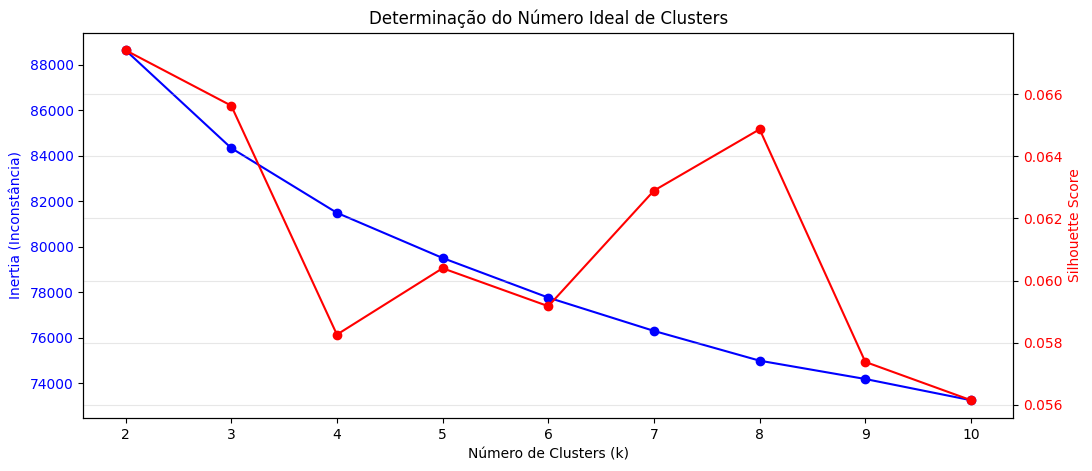

In [54]:
# 6.2 Determinação do número ideal de clusters
inertia = []
silhouette_scores = []
k_range = range(2, 11)

for k in k_range:
    km = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10)
    labels = km.fit_predict(X_clust_scaled)
    inertia.append(km.inertia_)
    silhouette_scores.append(silhouette_score(X_clust_scaled, labels))

# Visualização das heurísticas
fig, ax1 = plt.subplots(figsize=(12, 5))

ax1.plot(k_range, inertia, 'bo-', label='Inertia (Elbow)')
ax1.set_xlabel('Número de Clusters (k)')
ax1.set_ylabel('Inertia (Inconstância)', color='b')
ax1.tick_params(axis='y', labelcolor='b')

ax2 = ax1.twinx()
ax2.plot(k_range, silhouette_scores, 'ro-', label='Silhouette Score')
ax2.set_ylabel('Silhouette Score', color='r')
ax2.tick_params(axis='y', labelcolor='r')

plt.title('Determinação do Número Ideal de Clusters')
plt.grid(True, alpha=0.3)
plt.show()

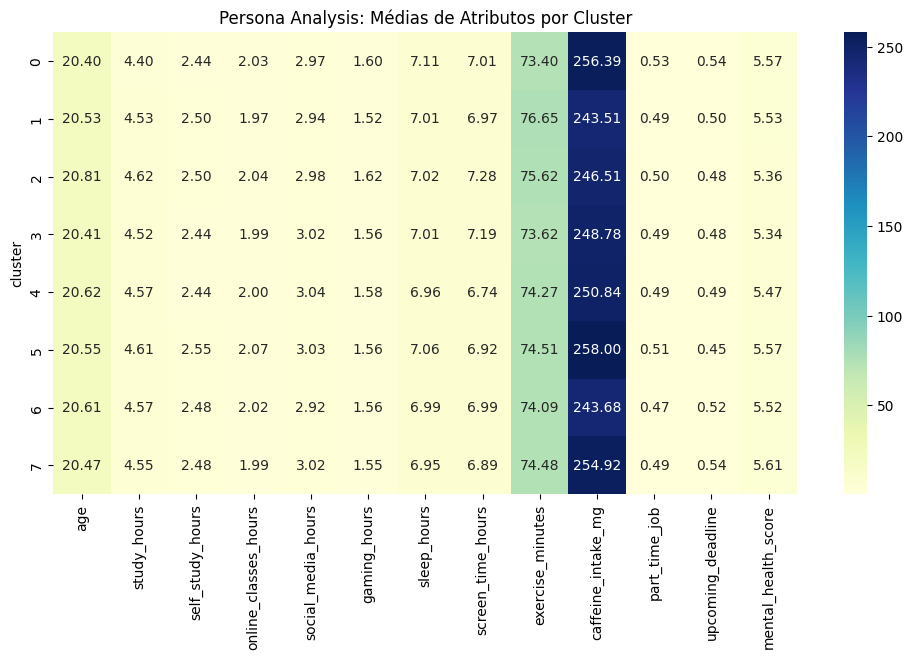

In [55]:
# 6.3 Aplicação do K-Means e Análise de Perfis
optimal_k = 8 # Exemplo baseado na observação dos gráficos acima
kmeans_final = KMeans(n_clusters=optimal_k, random_state=RANDOM_STATE, n_init=10)
df['cluster'] = kmeans_final.fit_predict(X_clust_scaled)

# Cálculo das médias por cluster para variáveis numéricas relevantes
cols_to_profile = [col for col in df.columns if col not in ['student_id', 'focus_index', 'exam_score', 'high_exam_score', 'burnout_level', 'productivity_score', 'cluster']]
cluster_profiles = df.groupby('cluster')[cols_to_profile].mean(numeric_only=True)

plt.figure(figsize=(12, 6))
sns.heatmap(cluster_profiles, annot=True, cmap='YlGnBu', fmt=".2f")
plt.title('Persona Analysis: Médias de Atributos por Cluster')
plt.show()

In [56]:
def describe_personas(profiles, global_mean):
    print("=== Descrição das Personas (Destaques em relação à média global) ===\n")
    for cluster_id in profiles.index:
        print(f"Cluster {cluster_id}:")
        diff = profiles.loc[cluster_id] - global_mean
        
        # Identifica os traços com maior desvio (positivo e negativo)
        top_traits = diff.sort_values(ascending=False)
        high = top_traits.index[top_traits > 0][:2].tolist()
        low = top_traits.index[top_traits < 0][-2:].tolist()
        
        print(f"  - Acima da média: {', '.join(high)}")
        print(f"  - Abaixo da média: {', '.join(low)}")
        
# --- Lógica de Definição de Personas ---
        if 'caffeine_intake_mg' in high and 'sleep_hours' in high:
            persona = "O Procrastinador Descansado (Dorme muito, consome cafeína, pouco estudo e exercício)"
            
        elif 'exercise_minutes' in high and 'mental_health_score' in high:
            persona = "O Atleta Zen (Muito ativo, excelente saúde mental, longe das redes sociais)"
            
        elif 'exercise_minutes' in high and 'screen_time_hours' in high:
            persona = "O Ativo Digitalmente Exausto (Fisicamente ativo, mas desgastado pelos ecrãs e com saúde mental baixa)"
            
        elif 'screen_time_hours' in high and 'social_media_hours' in high:
            persona = "O Sedentário Digital (Foco total em redes sociais e ecrãs, sem qualquer exercício)"
            
        elif 'age' in high and 'social_media_hours' in high:
            persona = "O Veterano Conectado (Estudante mais velho, muito ativo no mundo digital, mas pouco ativo fisicamente)"
            
        elif 'caffeine_intake_mg' in high and 'self_study_hours' in high:
            persona = "O Rato de Biblioteca Cafeinado (Muito estudo autónomo à base de café, baixo tempo de ecrã)"
            
        elif 'age' in high and 'study_hours' in high:
            persona = "O Veterano Aplicado (Estudante mais velho com carga elevada de estudo, sedentário e sem consumo de cafeína)"
            
        elif 'caffeine_intake_mg' in high and 'mental_health_score' in high:
            persona = "O Focado Produtivo (Muita cafeína, poucas horas de sono/ecrã, mas com saúde mental resiliente)"
            
        else:
            persona = "Perfil Intermédio / Equilibrado (Sem desvios extremos)"

        print(f"  > Persona Sugerida: {persona}")
        print("-" * 30)
global_avg = df[cols_to_profile].mean(numeric_only=True)
describe_personas(cluster_profiles, global_avg)

=== Descrição das Personas (Destaques em relação à média global) ===

Cluster 0:
  - Acima da média: caffeine_intake_mg, sleep_hours
  - Abaixo da média: study_hours, exercise_minutes
  > Persona Sugerida: O Procrastinador Descansado (Dorme muito, consome cafeína, pouco estudo e exercício)
------------------------------
Cluster 1:
  - Acima da média: exercise_minutes, mental_health_score
  - Abaixo da média: social_media_hours, caffeine_intake_mg
  > Persona Sugerida: O Atleta Zen (Muito ativo, excelente saúde mental, longe das redes sociais)
------------------------------
Cluster 2:
  - Acima da média: exercise_minutes, screen_time_hours
  - Abaixo da média: mental_health_score, caffeine_intake_mg
  > Persona Sugerida: O Ativo Digitalmente Exausto (Fisicamente ativo, mas desgastado pelos ecrãs e com saúde mental baixa)
------------------------------
Cluster 3:
  - Acima da média: screen_time_hours, social_media_hours
  - Abaixo da média: exercise_minutes, caffeine_intake_mg
  > Person

# 4. Interpretabilidade e Análise Comparativa

Nesta secção, aplicamos técnicas de interpretação agnóstica para compreender o comportamento dos modelos complexos e compará-los com as referências lineares da Fase I. O objetivo é validar se as decisões dos modelos fazem sentido do ponto de vista do domínio (educação/estudantes) e identificar porque é que os modelos falham em determinados casos.

## 4.1 Configuração da Análise SHAP

Utilizaremos o **SHAP (SHapley Additive exPlanations)** para decompor a previsão de cada modelo no contributo individual de cada atributo. Para a comparação, focaremos na tarefa de classificação (`high_exam_score`), analisando o **Random Forest** (Tuned) vs **Regressão Logística** (Tuned).

In [57]:
import shap

# Garantir que os modelos estão carregados
best_rf_model = grid_rf.best_estimator_
best_log_model = grid_log.best_estimator_

# Nomes das colunas selecionadas
selected_features_names = feature_names[clf_selector.get_support()]

# Explicador para Random Forest (TreeExplainer é otimizado para árvores)
explainer_rf = shap.TreeExplainer(best_rf_model)
shap_values_rf = explainer_rf.shap_values(X_test_clf_selected)

# Explicador para Regressão Logística (LinearExplainer)
explainer_log = shap.LinearExplainer(best_log_model, X_train_clf_selected)
shap_values_log = explainer_log.shap_values(X_test_clf_selected)

## 4.2 Seleção de Exemplos: TP, TN, FP, FN

Identificamos instâncias específicas no conjunto de teste onde o modelo Random Forest acertou e falhou, para observar como os atributos influenciaram essas previsões.

In [58]:
y_pred_rf = best_rf_model.predict(X_test_clf_selected)

# Encontrar índices para cada categoria
tp_idx = np.where((y_test_clf == 1) & (y_pred_rf == 1))[0][0]
tn_idx = np.where((y_test_clf == 0) & (y_pred_rf == 0))[0][0]
fp_idx = np.where((y_test_clf == 0) & (y_pred_rf == 1))[0][0]
fn_idx = np.where((y_test_clf == 1) & (y_pred_rf == 0))[0][0]

cases = {'True Positive (Sucesso previsto corretamente)': tp_idx, 
         'True Negative (Não-sucesso previsto corretamente)': tn_idx, 
         'False Positive (Alarme Falso)': fp_idx, 
         'False Negative (Falha na deteção)': fn_idx}

for label, idx in cases.items():
    print(f"{label}: Index {idx}")

True Positive (Sucesso previsto corretamente): Index 1
True Negative (Não-sucesso previsto corretamente): Index 0
False Positive (Alarme Falso): Index 5
False Negative (Falha na deteção): Index 14


## 4.3 Análise Comparativa Visual

Para cada caso, apresentamos a importância local das features. No gráfico SHAP, valores à direita (positivo) aumentam a probabilidade de ser classe 1 (`high_exam_score`), e à esquerda diminuem.


ANÁLISE DO CASO: True Positive (Sucesso previsto corretamente)
--- Explicação Random Forest (Black-Box) ---


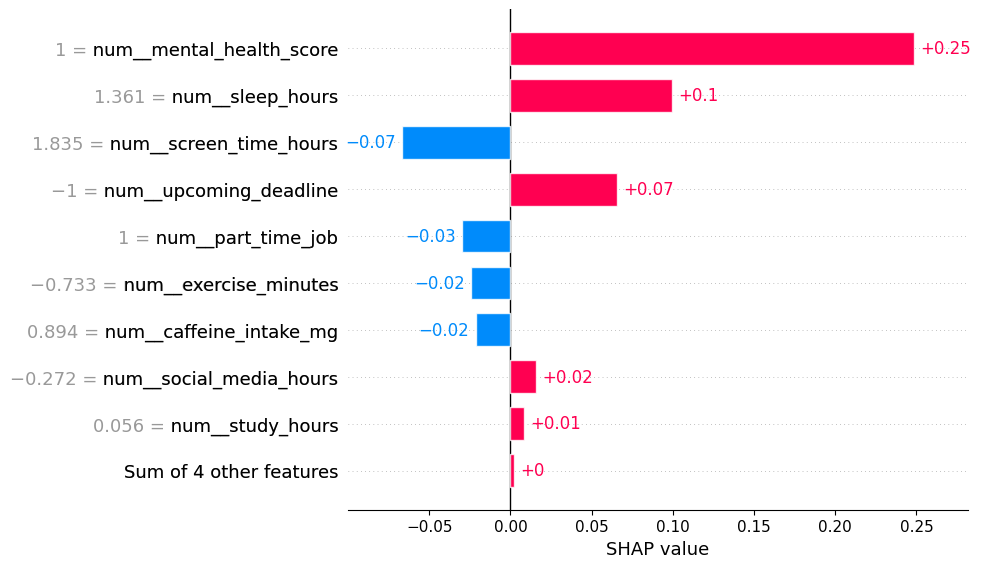

--- Explicação Regressão Logística (Interpretável) ---


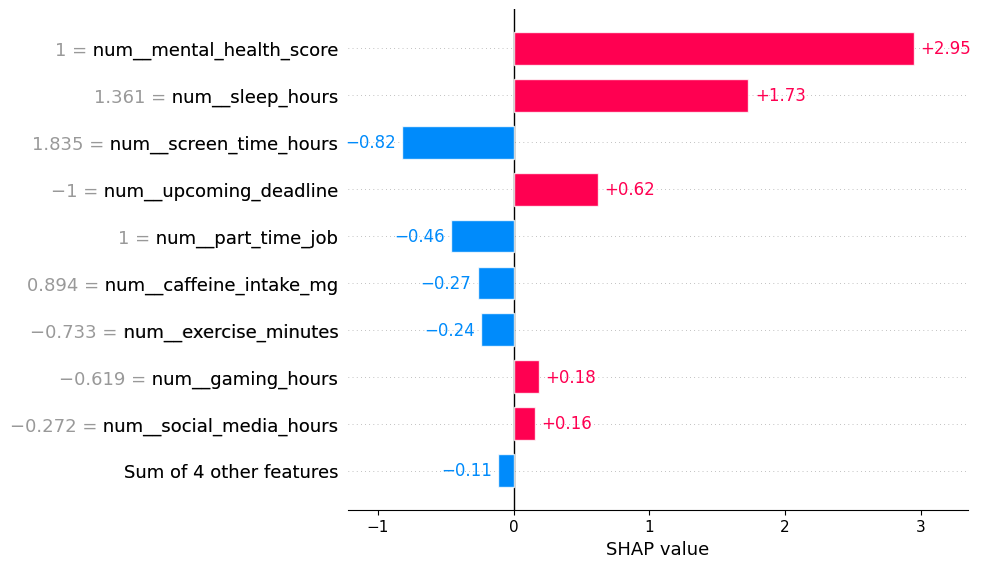


ANÁLISE DO CASO: True Negative (Não-sucesso previsto corretamente)
--- Explicação Random Forest (Black-Box) ---


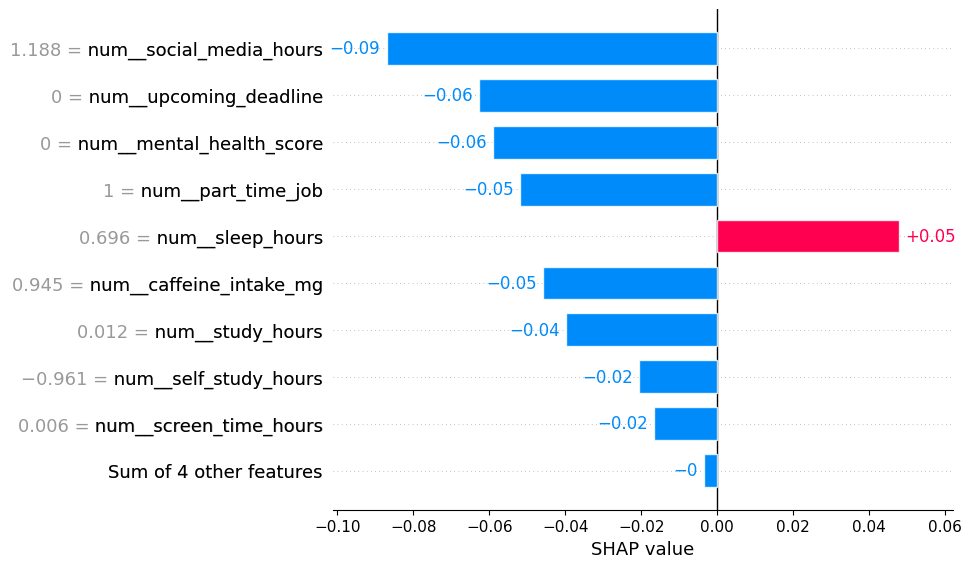

--- Explicação Regressão Logística (Interpretável) ---


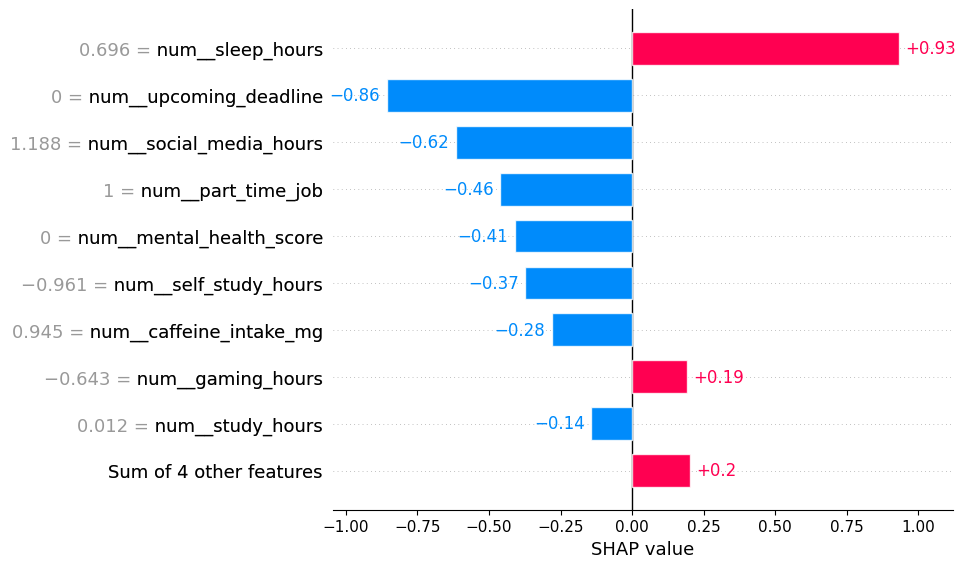


ANÁLISE DO CASO: False Positive (Alarme Falso)
--- Explicação Random Forest (Black-Box) ---


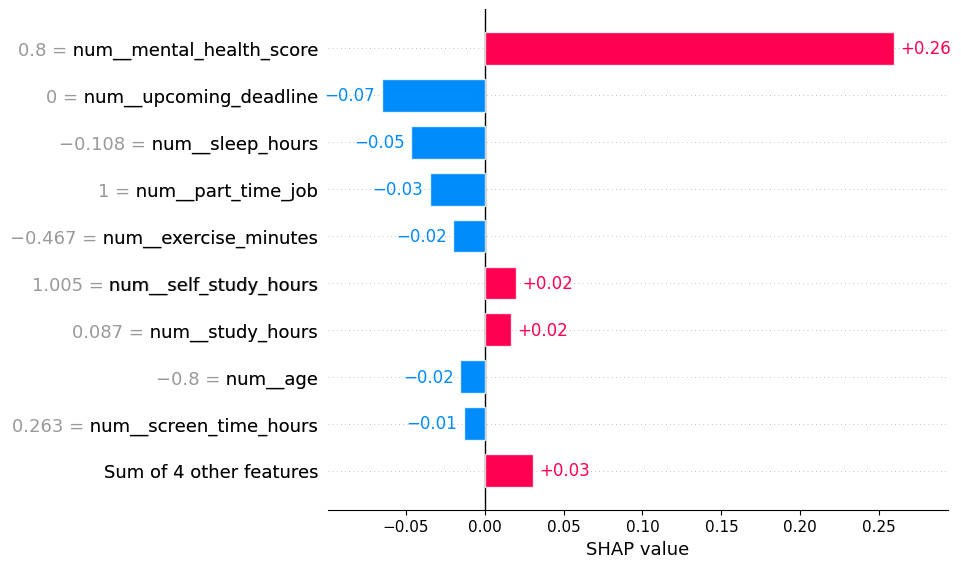

--- Explicação Regressão Logística (Interpretável) ---


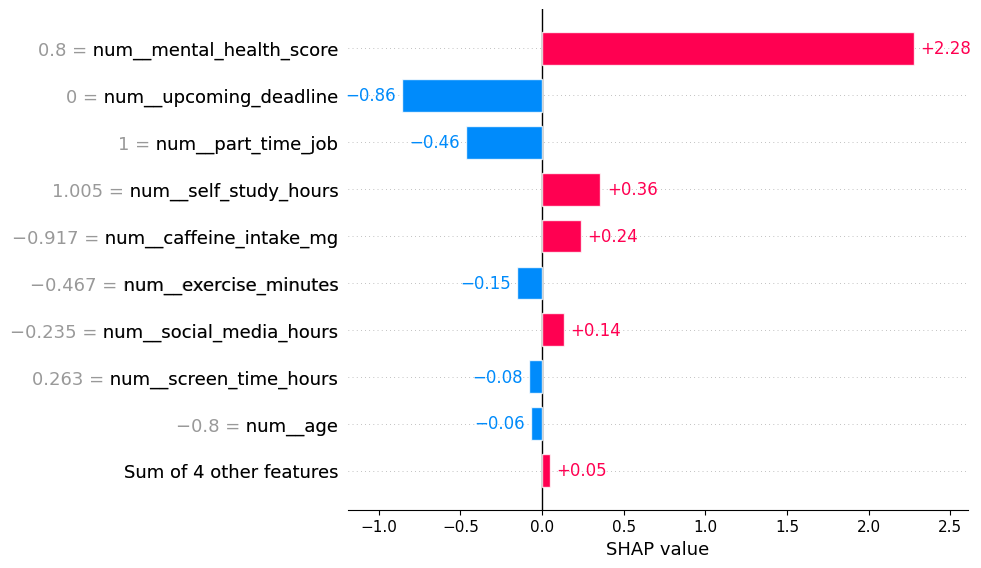


ANÁLISE DO CASO: False Negative (Falha na deteção)
--- Explicação Random Forest (Black-Box) ---


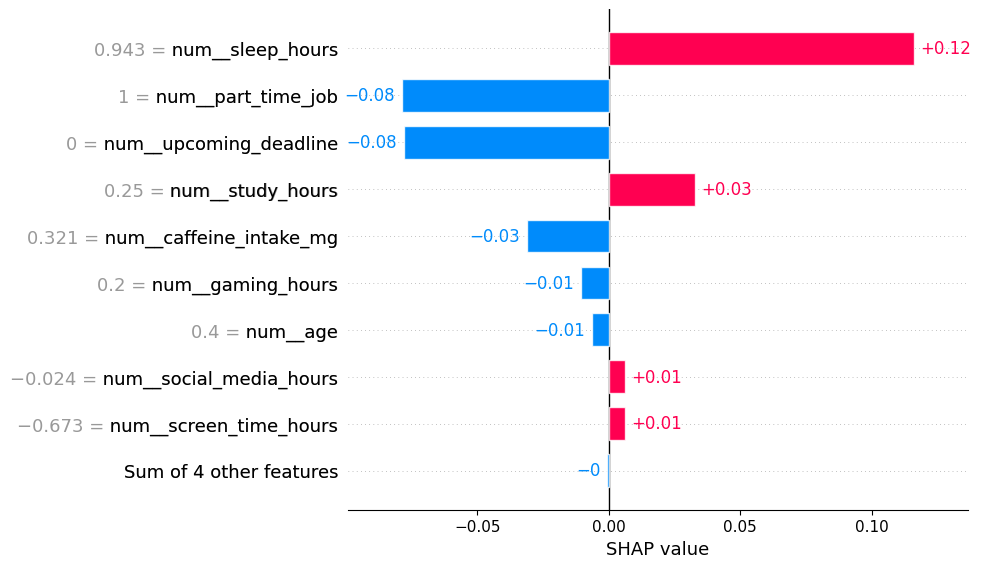

--- Explicação Regressão Logística (Interpretável) ---


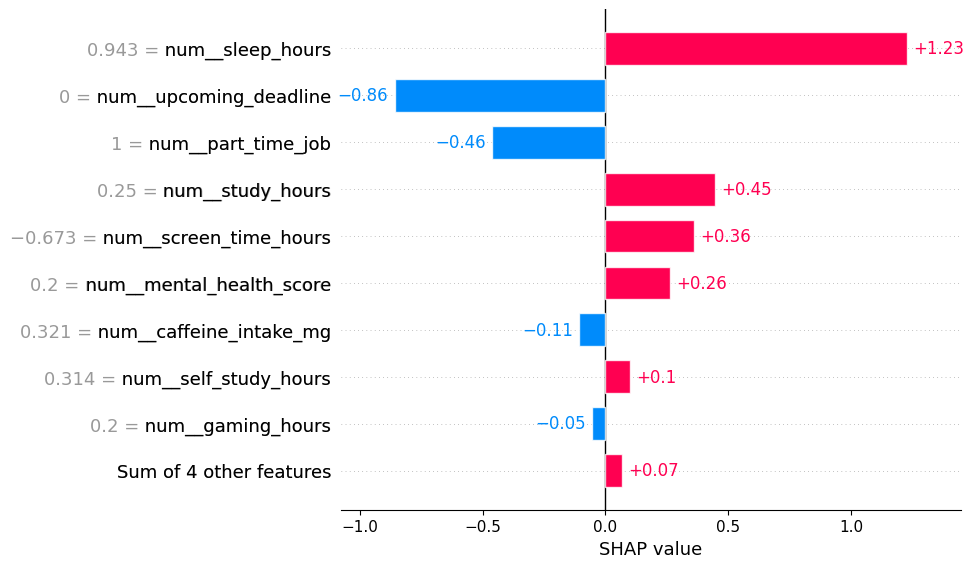

In [59]:
for label, idx in cases.items():
    print(f"\n" + "="*50)
    print(f"ANÁLISE DO CASO: {label}")
    print("="*50)
    
    # No RF, shap_values_rf pode vir como lista [valores_classe_0, valores_classe_1]
    # Queremos a explicação para a classe 1 (desempenho elevado)
    current_shap_rf = shap_values_rf[idx, :, 1] if shap_values_rf.ndim == 3 else shap_values_rf[1][idx]
    
    plt.figure(figsize=(12, 4))
    print("--- Explicação Random Forest (Black-Box) ---")
    shap.plots.bar(shap.Explanation(values=current_shap_rf, 
                                    feature_names=selected_features_names,
                                    data=X_test_clf_selected[idx]), show=False)
    plt.show()

    print("--- Explicação Regressão Logística (Interpretável) ---")
    plt.figure(figsize=(12, 4))
    # Na Regressão Logística, a explicação é baseada nos pesos (C * feature_value)
    current_shap_log = shap_values_log[idx]
    shap.plots.bar(shap.Explanation(values=current_shap_log, 
                                    feature_names=selected_features_names,
                                    data=X_test_clf_selected[idx]), show=False)
    plt.show()

### 4.4 Hipóteses e Conclusões sobre a Interpretabilidade

A aplicação da técnica SHAP permitiu desconstruir o processo de decisão do modelo *Black-Box* (Random Forest) e compará-lo com o modelo intrinsecamente interpretável (Regressão Logística). A análise de quatro casos extremos (Verdadeiro Positivo, Verdadeiro Negativo, Falso Positivo e Falso Negativo) revelou dinâmicas distintas na forma como cada algoritmo pondera os atributos.

Com base na observação das explicações locais geradas, formulamos as seguintes hipóteses:

**Hipóteses sobre a Concordância (Casos TP e TN):**
* **Sinal forte e linear:** Nos casos em que ambos os modelos acertam com elevada confiança (Verdadeiros Positivos e Verdadeiros Negativos), observamos uma forte concordância no *Top 3* de atributos mais influentes (ex: `num_mental_health_score` e `num_sleep_hours`). A nossa hipótese é que, nestes cenários, a relação entre os dados e a variável-alvo é predominantemente linear. Como a Regressão Logística é excelente a capturar dependências lineares diretas, o seu comportamento aproxima-se muito do modelo de *ensemble*.
* **Diferença de Espaço de Decisão:** Apesar de concordarem na direção do impacto (positivo ou negativo), a escala dos valores SHAP difere. Isto ocorre porque o SHAP aplicado à Regressão Logística está a explicar a variação nos *log-odds* (que não têm limite superior ou inferior), enquanto a Random Forest explica a alteração direta na probabilidade da classe (limitada entre 0 e 1).

**Hipóteses sobre a Discordância e Erro (Casos FP e FN):**
* **Incapacidade de captar interações não-lineares (O erro da Regressão Logística):** Nos casos em que a Regressão Logística falha, observamos que o modelo tende a penalizar ou premiar excessivamente uma única variável extrema. A hipótese é que este modelo atribui um "peso fixo" a cada atributo. Por exemplo, se o `num_screen_time_hours` for muito elevado, a Regressão Logística pode forçar uma previsão negativa. A Random Forest, por sua vez, consegue entender que um tempo de ecrã elevado pode não ser prejudicial se for acompanhado por ausência de prazos (`num_upcoming_deadline = 0`) e bom tempo de sono, demonstrando a sua capacidade de captar interações complexas entre atributos.
* **Sensibilidade a Ruído ou *Overfitting* Local (O erro da Random Forest):** Nos Falsos Positivos gerados pela Random Forest, a hipótese é que as árvores de decisão podem ter ramificado com base em regras excessivamente específicas do conjunto de treino que não se generalizaram bem. Pequenas variações em atributos de menor importância global podem ter empurrado a probabilidade ligeiramente acima do limiar de decisão num nó específico da árvore.

**Conclusão:**
A análise comparativa evidencia o clássico compromisso (*trade-off*) entre interpretabilidade e complexidade. A Regressão Logística oferece uma transparência total sobre a magnitude e direção do peso de cada variável. Contudo, a Random Forest prova ser mais robusta ao modelar a realidade dos estudantes, uma vez que o comportamento humano é inerentemente não-linear e cheio de dependências cruzadas que um modelo linear simples não consegue captar.

### 4.